# Carnet d'ordres : modélisation stochastique du Bid et de l'Ask

Ce notebook étudie la dynamique d'un carnet d'ordres simplifié dans lequel les volumes au meilleur **Bid** ($q_b$) et au meilleur **Ask** ($q_a$) sont modélisés par des processus de comptage. On part d'un modèle Markov (processus de Poisson) puis on enrichit progressivement le cadre :

1. **Modèle Poisson** indépendant pour le bid et l'ask.
2. **Estimation Monte-Carlo** de l'espérance du temps d'atteinte de 0.
3. **Trajectoires conjointes** dans le plan $(q_b, q_a)$.
4. **Approximation diffusive** par un mouvement brownien avec dérive (régime fluide).
5. **Loi inverse-gaussienne** du premier temps d'atteinte de 0.
6. **Probabilité de ruine asymétrique** $\mathbb{P}(\tau_a < \tau_b)$ — surface 3D.
7. **Surface 3D** du temps moyen $\mathbb{E}[\min(\tau_a, \tau_b)]$ avec intervalles de confiance.
8. **Processus de Hawkes** : intensité auto-excitée et simulation par thinning d'Ogata.
9. **Hawkes couplés** entre bid et ask (excitation croisée).
10. **Comparaison** des distributions de temps d'arrêt sous les différents modèles.
11. **Processus auxiliaire** $q_2$ représentant un autre niveau du carnet, conditionné par le côté qui s'épuise en premier.
12. **Intensité $\lambda^+_2$ excitée** par les décréments de l'ask (couplage vers le niveau adjacent).

Notations principales : $\lambda^+, \lambda^-$ intensités constantes ; $\mu^-, \alpha, \beta$ paramètres de Hawkes (taux de fond, gain de saut, taux de relaxation) ; $\tau_a, \tau_b$ premiers temps d'atteinte de 0.

## 0. Choix des paramètres

Les valeurs numériques utilisées dans tout le notebook sont rassemblées ci-dessous, avec leur justification.

| Paramètre | Valeur | Rôle | Justification |
|---|---|---|---|
| $\lambda^+$ | $1.2$ | Intensité d'arrivée (insertion limite) | Choisi *plus petit que* $\lambda^-$ pour assurer un drift négatif $\mu = \lambda^+ - \lambda^- = -0.8 < 0$, garantissant l'atteinte presque-sûre de 0. |
| $\lambda^-$ | $2.0$ | Intensité d'arrivée (annulation / consommation) | Idem, et donne $\sigma^2 = \lambda^+ + \lambda^- = 3.2$, $|\mu|/\sigma \approx 0.45$ (régime ni trop diffusif, ni trop drifté). |
| $T$ | $100$ | Horizon temporel des trajectoires « étalon » | $T \gg \mathbb E[\tau] \approx 12.5$ pour le BM, donc largement assez pour capter plusieurs régimes ; suffisamment court pour que les figures restent lisibles. |
| $Q_0,\ Q_0^A,\ Q_0^B,\ Q_0^{(2)}$ | $10$ | Volume initial au meilleur niveau | Compromis : assez grand pour que l'approximation diffusive (régime fluide) soit pertinente ($q_0 \gg 1$) ; assez petit pour que $\mathbb E[\tau]$ reste de l'ordre de la dizaine d'unités de temps. |
| $\mu^-$ (Hawkes) | $2.0$ | Intensité de fond Hawkes | Égale à $\lambda^-$ pour comparer Hawkes et Poisson à régime équivalent en l'absence d'événement. |
| $\alpha$ | $0.5$ | Gain de saut Hawkes | Choisi de sorte que $\alpha < \beta$ (stabilité), avec $\alpha/\beta = 0.5$ (excitation modérée mais visible). |
| $\beta$ | $1.0$ | Taux de relaxation Hawkes | Échelle de temps de mémoire $1/\beta = 1$, du même ordre que l'inter-événement moyen $1/(\lambda^++\lambda^-) \approx 0.31$. |
| $\bar\lambda^-_\infty$ | $2.8$ | Moyenne stationnaire Hawkes | Conséquence directe de $(\mu^-\beta - \lambda^+\alpha)/(\beta-\alpha)$. Vérifiée numériquement. |
| $\lambda^+_2,\ \lambda^-_2$ | $1.2,\ 2.0$ | Intensités du processus auxiliaire $q_2$ | Mêmes que le niveau principal pour observer une dynamique comparable. |
| $a$ | $0.5$ | Excitation de $\lambda^+_2$ par chaque baisse d'ask | Calibré pour produire un effet visible sans déstabiliser ($a \ll \mu^+_2$). |
| $b$ | $1.0$ | Taux de décroissance de l'excitation sur $q_2$ | Même échelle de mémoire que $\beta$ pour cohérence. |
| $dt$ | $0.01$ | Pas du schéma d'Euler-Maruyama (BM) | $dt \cdot \sigma^2 = 0.032 \ll q_0^2$ : biais de discrétisation négligeable devant $q_0$. |
| `num_simulations` | $1000$ (estimation), $5000$ (KS), $300$ (surfaces 3D Poisson), $200$ (surfaces 3D Hawkes couplé) | Taille des échantillons MC | Donne $\hat\sigma/\sqrt M \approx 0.01\,\hat T$ pour $M=1000$ (IC à 95% de largeur ≈ 5%). Réduit à 300/200 pour les surfaces $10\times 10$ qui demandent $100\times M$ trajectoires (compromis temps/précision). |
| $q_{\max}$ | $10$ | Taille de la grille des surfaces 3D | Donne $10\times 10 = 100$ points, suffisant pour visualiser la forme tout en restant accessible (en pratique, le calcul Hawkes couplé prend déjà plusieurs minutes). |

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps

# Reproductibilite : graine globale fixee une fois pour tout le notebook.
# Pour reproduire exactement les figures du rapport, executer les cellules
# dans l'ordre apres avoir relance ce noyau.
np.random.seed(0)


## 1. Modèle de base : processus de Poisson

On suppose que les arrivées d'ordres au meilleur Bid et au meilleur Ask sont régies par deux processus de Poisson indépendants :

- **Insertion** d'un ordre limite (saut $+1$) avec intensité $\lambda^+$,
- **Annulation** ou consommation par un ordre marché (saut $-1$) avec intensité $\lambda^-$.

Le volume au meilleur niveau $q$ suit ainsi un processus de naissance et mort sur $\mathbb{N}$,
$$q(t) = q(0) + N^+_{\lambda^+}(t) - N^-_{\lambda^-}(t),$$
absorbé en 0. Le temps inter-événements suit une loi exponentielle de paramètre $\lambda^+ + \lambda^-$, et chaque événement est un saut de $+1$ avec probabilité $\lambda^+/(\lambda^+ + \lambda^-)$, sinon $-1$. Pour étudier l'épuisement effectif, on prend $\lambda^- > \lambda^+$ (drift négatif) — c'est le réglage par défaut du notebook (`LAMBDA_PLUS = 1.2`, `LAMBDA_MINUS = 2`).

C'est exactement ce que simule la fonction `simulate_only_one_process`, et `simulate_poisson_process_until_zero` enchaîne les simulations indépendantes pour les côtés bid et ask.

In [46]:
LAMBDA_PLUS = 1.2
LAMBDA_MINUS = 2
LAMBDA_MINUS_2 = 2
LAMBDA_PLUS_2 = 1.2
T = 100
Q_0 = 10
Q_0_B = 10
Q_0_A = 10
Q_0_2 = 10

def simulate_only_one_process(lambda_plus, lambda_minus, q_0=Q_0_A, stopping_condition=lambda q,t: q > 0):
    q = q_0
    times = [0]
    q_values = [q]
    while stopping_condition(q, times[-1]):
        total_rate = lambda_plus + lambda_minus
        time_to_next_event = np.random.exponential(1 / total_rate)
        times.append(times[-1] + time_to_next_event)
        if np.random.rand() < lambda_plus / total_rate:
            q += 1
        else:
            q -= 1
        q_values.append(max(0, q))  # Assurer que q ne devient pas négatif
    return times, q_values


def simulate_poisson_process_until_zero(lambda_plus, lambda_minus, q_0_a = Q_0_A, q_0_b = Q_0_B):
    times_b, q_b_values = simulate_only_one_process(lambda_plus, lambda_minus, q_0_b)
    times_a, q_a_values = simulate_only_one_process(lambda_plus, lambda_minus, q_0_a)
    return times_b, q_b_values, times_a, q_a_values

def plot_poisson_process(times_b, q_b_values, times_a, q_a_values):
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.step(times_b, q_b_values, where='post')
    plt.title('Évolution de q_b au fil du temps')
    plt.xlabel('Temps')
    plt.ylabel('q_b')
    plt.grid()
    plt.subplot(2, 1, 2)
    plt.step(times_a, q_a_values, where='post')
    plt.title('Évolution de q_a au fil du temps')
    plt.xlabel('Temps')
    plt.ylabel('q_a')
    plt.tight_layout()
    plt.grid()
    plt.show()


def plot_combined(times_b, q_b_values, times_a, q_a_values):
    plt.figure()
    plt.plot(times_b, q_b_values, label='q_b')
    plt.plot(times_a, q_a_values, label='q_a')
    plt.title('Évolution de q_b et q_a au fil du temps')
    plt.xlabel('Temps')
    plt.ylabel('Quantité')
    plt.grid()
    plt.legend()
    plt.show()



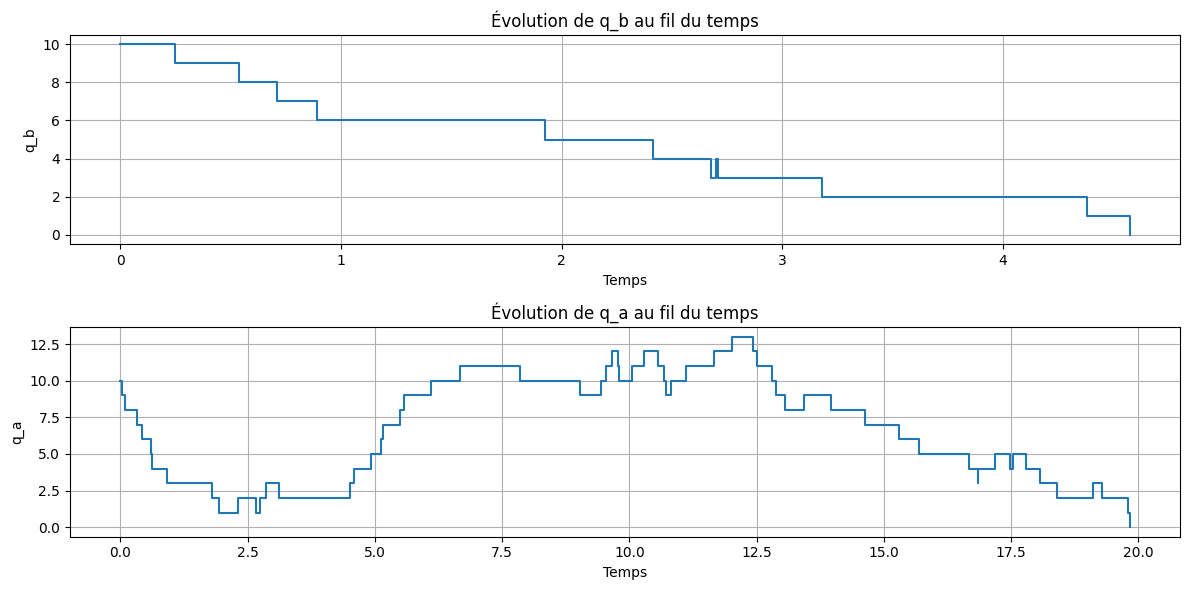

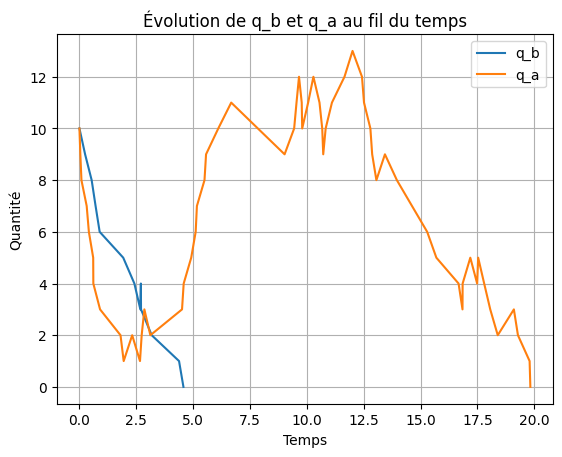

In [47]:
times_b, q_b_values, times_a, q_a_values = simulate_poisson_process_until_zero(LAMBDA_PLUS, LAMBDA_MINUS)
plot_poisson_process(times_b, q_b_values, times_a, q_a_values)
plot_combined(times_b, q_b_values, times_a, q_a_values)

## 2. Estimation Monte-Carlo de l'espérance du temps d'atteinte de 0

Pour estimer
$$\mathbb{E}[\tau], \qquad \tau = \inf\{t \ge 0 : q(t) = 0\},$$
on tire $M$ trajectoires indépendantes et on calcule la moyenne empirique
$$\hat{\mathbb{E}}[\tau] = \frac{1}{M}\sum_{i=1}^M \tau^{(i)}, \qquad \mathrm{IC}_{1-\alpha} = \hat{\mathbb{E}}[\tau] \pm z_{1-\alpha/2}\,\frac{\hat\sigma}{\sqrt{M}},$$
où $\hat\sigma$ est l'écart-type empirique. L'intervalle de confiance est asymptotiquement valide par TCL (les $\tau^{(i)}$ ont une variance finie sous $\lambda^- > \lambda^+$).

On distingue deux estimateurs :

- `estimate_time_to_zero_for_one_process` : $\mathbb{E}[\tau]$ pour un seul processus (file isolée).
- `estimate_time_to_zero` : $\mathbb{E}[\min(\tau_a, \tau_b)]$ pour deux files indépendantes (premier des deux à toucher 0).

In [48]:
def estimate_time_to_zero(lambda_plus, lambda_minus, q_0_a=Q_0_A, q_0_b=Q_0_B, num_simulations=1000, quantile = 0.95):
    times_to_zero = []
    for _ in range(num_simulations):
        times_b, _, times_a, _ = simulate_poisson_process_until_zero(lambda_plus, lambda_minus, q_0_a, q_0_b)
        times_to_zero.append(min(times_b[-1], times_a[-1]))
    estimate = np.mean(times_to_zero)
    z_score = sps.norm.ppf((1+quantile)/2)
    upper_IC_bound = estimate + z_score * np.std(times_to_zero) / np.sqrt(num_simulations)
    lower_IC_bound = estimate - z_score * np.std(times_to_zero) / np.sqrt(num_simulations)
    print (f"Temps moyen estimé pour que q_a ou q_b atteigne zéro : {estimate:.2f} unités de temps")
    print(f"Intervalle de confiance à {quantile*100:.0f}% pour le temps moyen : [{lower_IC_bound}, {upper_IC_bound}]")
    return estimate, lower_IC_bound, upper_IC_bound

def estimate_time_to_zero_for_one_process(lambda_plus, lambda_minus, q_0=Q_0_A, num_simulations=1000, quantile = 0.95):
    times_to_zero = []
    for _ in range(num_simulations):
        q = q_0
        time = 0
        while q > 0:
            total_rate = lambda_plus + lambda_minus
            time_to_next_event = np.random.exponential(1 / total_rate)
            time += time_to_next_event
            if np.random.rand() < lambda_plus / total_rate:
                q += 1
            else:
                q -= 1
        times_to_zero.append(time)
    estimate = np.mean(times_to_zero)
    z_score = sps.norm.ppf((1+quantile)/2)
    upper_IC_bound = estimate + z_score * np.std(times_to_zero) / np.sqrt(num_simulations)
    lower_IC_bound = estimate - z_score * np.std(times_to_zero) / np.sqrt(num_simulations)
    print (f"Temps moyen estimé pour que le processus {q_0},{lambda_minus},{lambda_plus} atteigne zéro : {estimate:.2f} unités de temps")
    print(f"Intervalle de confiance à {quantile*100:.0f}% pour le temps moyen du processus {q_0},{lambda_minus},{lambda_plus} : [{lower_IC_bound}, {upper_IC_bound}]")
    return estimate, lower_IC_bound, upper_IC_bound

In [49]:
estimate1, lower_IC_bound1, upper_IC_bound1 = estimate_time_to_zero(LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=1000, quantile=0.95)
estimate1, lower_IC_bound1, upper_IC_bound1 = estimate_time_to_zero_for_one_process(LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=1000, quantile=0.95)

Temps moyen estimé pour que q_a ou q_b atteigne zéro : 8.45 unités de temps
Intervalle de confiance à 95% pour le temps moyen : [8.196947843526466, 8.709809496517668]
Temps moyen estimé pour que le processus 10,2,1.2 atteigne zéro : 12.41 unités de temps
Intervalle de confiance à 95% pour le temps moyen du processus 10,2,1.2 : [11.925697854699397, 12.895918764435546]


## 3. Trajectoire dans le plan $(q_b, q_a)$

On peut visualiser conjointement les deux files en traçant la trajectoire $(q_b(t), q_a(t))$ dans le plan jusqu'au premier passage à 0 d'une des deux. Comme les deux processus ont leurs propres temps d'événement, on synchronise les échelles de temps via une recherche binaire (`np.searchsorted`) sur les temps fusionnés, en O($n \log n$). La densité d'occupation des points $(q_b, q_a)$ est encodée dans la **transparence** : les états visités fréquemment apparaissent opaques, les transitoires restent translucides. Le point rouge marque le départ et le vert l'arrêt (un des deux côtés à 0).

In [50]:
def trajectory_grid(times_b, q_b_values, times_a, q_a_values):
    tb = np.array(times_b)
    ta = np.array(times_a)
    qb = np.array(q_b_values)
    qa = np.array(q_a_values)

    # O(n log n) merge: for each event time, find the last known q_b and q_a via binary search
    t_stop = min(tb[-1], ta[-1])                                     
    all_times = np.sort(np.concatenate([ta, tb]))
    all_times = all_times[all_times <= t_stop]
    q_B = qb[np.searchsorted(tb, all_times, side='right') - 1]
    q_A = qa[np.searchsorted(ta, all_times, side='right') - 1]

    # Count visits per (bid, ask) grid point
    points = np.stack([q_B, q_A], axis=1)
    _, inverse, unique_counts = np.unique(points, axis=0, return_inverse=True, return_counts=True)
    counts = unique_counts[inverse].astype(float)

    # Rare points → transparent, frequent points → opaque
    min_alpha = 0.5
    span = counts.max() - counts.min()
    alphas = min_alpha + (1 - min_alpha) * (counts - counts.min()) / (span if span > 0 else 1)

    rgba = np.column_stack([
        np.full(len(q_B), 0.2),
        np.full(len(q_B), 0.4),
        np.full(len(q_B), 0.8),
        alphas,
    ])

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot(q_B, q_A, color='blue', alpha=0.5, linewidth=0.5, zorder=1)
    ax.scatter(q_B[1:-1], q_A[1:-1], c=rgba[1:-1], s=40, zorder=2)
    ax.set_title('Trajectoire de (Bid, Ask) dans le plan')
    plt.scatter([q_B[0]], [q_A[0]], s=40, zorder=2, c='red', label='Début')
    plt.scatter([q_B[-1]], [q_A[-1]], s=40, zorder=2, c='green', label='Fin')
    plt.legend()
    ax.set_xlabel('Bid (q_b)')
    ax.set_ylabel('Ask (q_a)')
    plt.grid(alpha=0.3)
    plt.show()


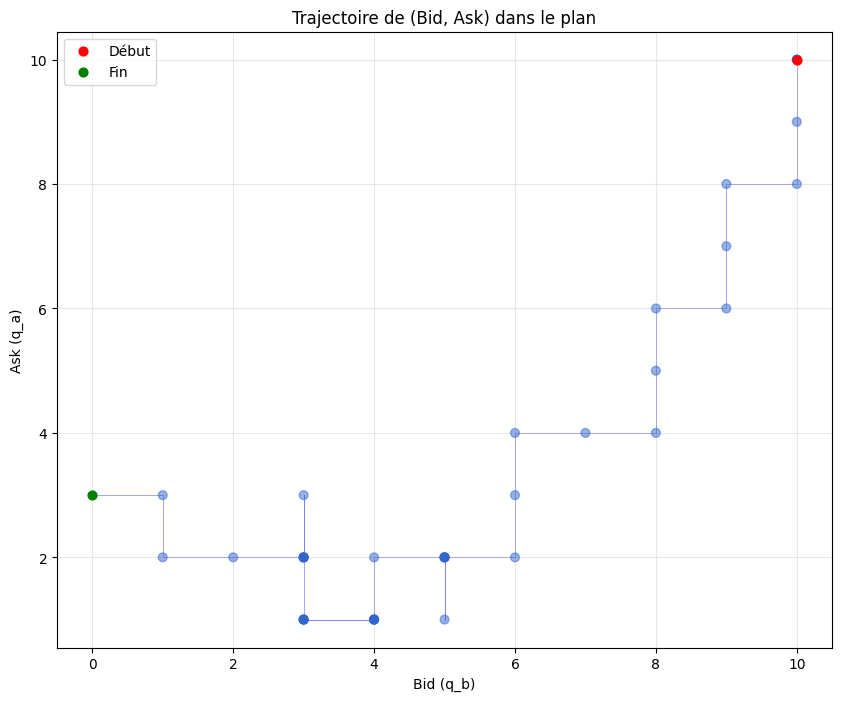

In [51]:
trajectory_grid(times_b, q_b_values, times_a, q_a_values)

## 4. Approximation diffusive (mouvement brownien avec dérive)

Lorsque les intensités $\lambda^\pm$ sont grandes (régime fluide), un théorème central limite fonctionnel pour les processus de Poisson centrés-renormalisés montre que
$$q(t) \;\xrightarrow[\lambda^\pm \to \infty]{}\; Q_t,$$
où $Q$ est solution de l'EDS
$$dQ_t = (\lambda^+ - \lambda^-)\,dt + \sqrt{\lambda^+ + \lambda^-}\,dW_t.$$

À l'instant $T$ (tant que la barrière 0 n'a pas été touchée), on a donc approximativement
$$q(T) \;\sim\; \mathcal{N}\!\left(q_0 + (\lambda^+ - \lambda^-)\,T,\; (\lambda^+ + \lambda^-)\,T\right).$$

L'histogramme des simulations Poisson est superposé à la densité gaussienne théorique pour valider visuellement cette approximation.

In [52]:
#Showing that Q_a can be approximated by a Brownian motion with drift lambda_plus - lambda_minus and variance lambda_plus + lambda_minus
def plot_approximation(T, lambda_plus, lambda_minus, num_simulations=1000, q_0 = Q_0_A):
    drift = lambda_plus - lambda_minus
    variance = lambda_plus + lambda_minus
    samples = []
    for _ in range(num_simulations):
        q = q_0
        t = 0
        while t < T:
            dt = np.random.exponential(1 / (lambda_plus + lambda_minus))
            t += dt
            q += 1 if np.random.rand() < lambda_plus / (lambda_plus + lambda_minus) else -1
        samples.append(q)
    plt.figure(figsize=(10, 6))
    plt.hist(samples, bins='auto', density=True, alpha=0.6, color='g', label='Simulations')
    x = np.linspace(min(samples), max(samples), 100)
    plt.plot(x, sps.norm.pdf(x, loc=q_0 + drift * T, scale=np.sqrt(variance * T)), 'r-', label='Approximation normale')
    plt.xlabel('q')
    plt.ylabel('Densité')
    plt.title('Distribution de q à l\'instant T')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


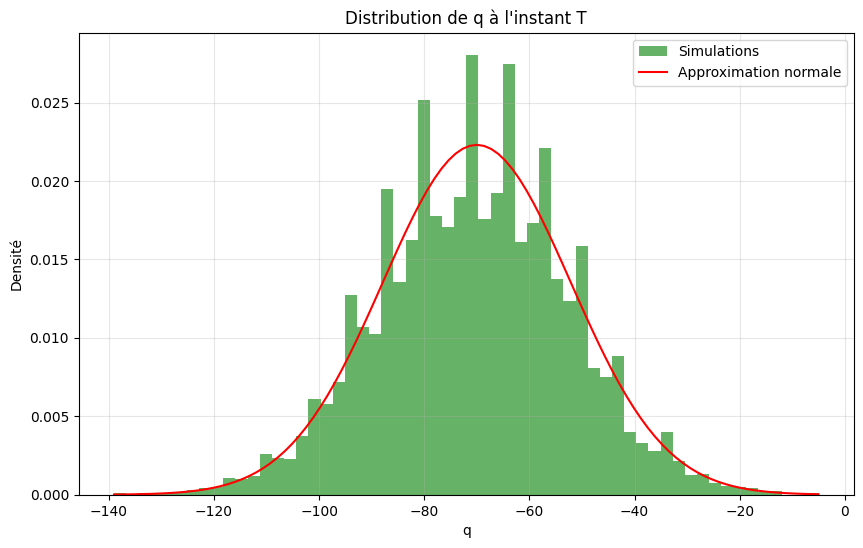

In [53]:
plot_approximation(100, LAMBDA_PLUS, LAMBDA_MINUS , num_simulations=10000, q_0 = Q_0_A)

## 5. Loi du temps d'atteinte de 0 (loi inverse-gaussienne)

Pour un mouvement brownien $X_t = q_0 + \mu t + \sigma W_t$ avec dérive **négative** ($\mu < 0$), le premier temps d'atteinte de 0
$$\tau = \inf\{t \ge 0 : X_t = 0\}$$
suit une **loi inverse-gaussienne** $\mathrm{IG}(\mu_{IG}, \lambda_{IG})$ de densité
$$f_\tau(t) = \sqrt{\frac{\lambda_{IG}}{2\pi t^3}}\,\exp\!\left(-\frac{\lambda_{IG}(t - \mu_{IG})^2}{2\,\mu_{IG}^2\,t}\right),$$
avec
$$\mu_{IG} = \frac{q_0}{|\mu|}, \qquad \lambda_{IG} = \frac{q_0^2}{\sigma^2}.$$

En convention SciPy, `sps.invgauss(mu = sigma**2 / (q_0 * |mu|), scale = q_0**2 / sigma**2)`. On compare ici la densité théorique à la fois à la simulation **Poisson exacte** (`stopping_time_distribution`) et à la simulation **brownienne discrétisée** (`stopping_time_distribution_brownian`), ce qui valide l'approximation diffusive sur la queue gauche du temps d'arrêt.

In [54]:
def stopping_time_distribution(lambda_plus, lambda_minus, q_0=Q_0_A, num_simulations=1000):
    stopping_times = []
    for _ in range(num_simulations):
        times, q_values = simulate_only_one_process(lambda_plus, lambda_minus, q_0)
        stopping_times.append(times[-1])
    drift = lambda_plus - lambda_minus
    sigma2 = lambda_plus + lambda_minus
    shape = q_0**2 / sigma2
    mu_sc = sigma2 / (q_0 * abs(drift))
    plt.figure(figsize=(10, 6))
    X = np.linspace(0.01, max(stopping_times), 300)
    plt.plot(X, sps.invgauss.pdf(X, mu=mu_sc, scale=shape), 'r-', label='Distribution inverse gaussienne théorique')
    plt.hist(stopping_times, bins='auto', density=True, alpha=0.6, color='b', label='Simulation Poisson')
    plt.xlabel("Temps jusqu'à ce que q atteigne zéro")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'arrêt pour q")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def simulate_brownian_motion_until_zero(drift, variance, q_0=Q_0_A, dt=0.01):
    q = q_0
    t = 0.0
    while q > 0:
        q_prev = q
        t_prev = t
        q += drift * dt + np.sqrt(variance * dt) * np.random.randn()
        t += dt
    frac = q_prev / (q_prev - q)
    return t_prev + frac * dt

def stopping_time_distribution_brownian(drift, variance, q_0=Q_0_A, num_simulations=1000):
    stopping_times = [simulate_brownian_motion_until_zero(drift, variance, q_0) for _ in range(num_simulations)]
    shape = q_0**2 / variance
    mu_sc = variance / (q_0 * abs(drift))
    plt.figure(figsize=(10, 6))
    X = np.linspace(0.01, max(stopping_times), 300)
    plt.plot(X, sps.invgauss.pdf(X, mu=mu_sc, scale=shape), 'r-', label='Distribution inverse gaussienne théorique')
    plt.hist(stopping_times, bins='auto', density=True, alpha=0.6, color='m', label='Simulation Brownienne')
    plt.xlabel("Temps jusqu'à ce que q atteigne zéro (Brownien)")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'arrêt pour le processus brownien")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

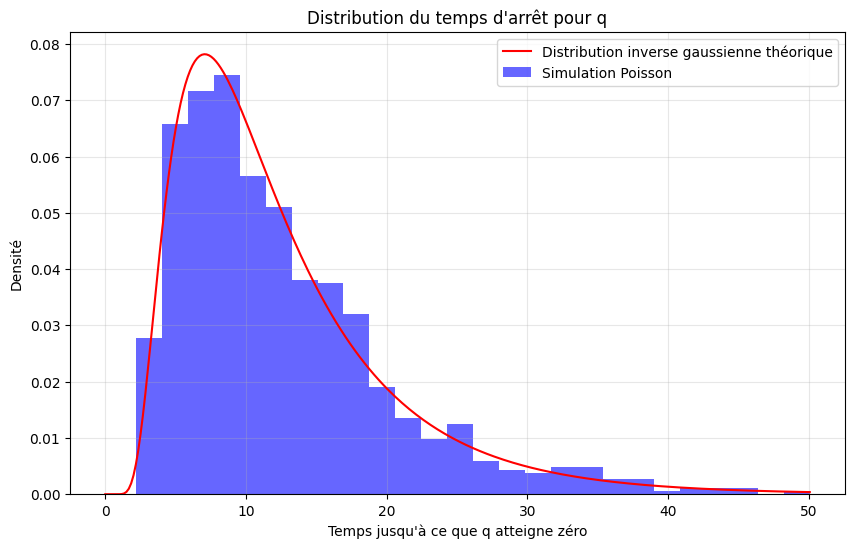

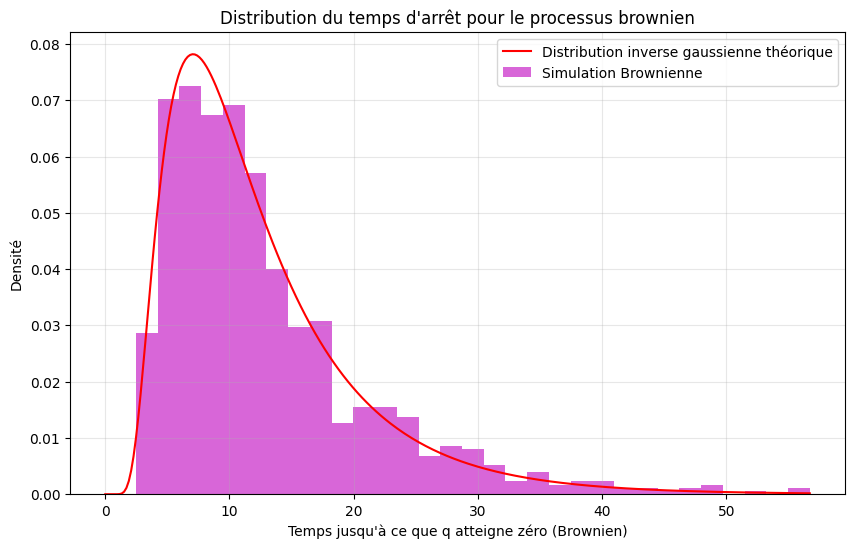

In [55]:
stopping_time_distribution(LAMBDA_PLUS, LAMBDA_MINUS, q_0=Q_0_A, num_simulations=1000)
stopping_time_distribution_brownian(LAMBDA_PLUS - LAMBDA_MINUS, LAMBDA_PLUS + LAMBDA_MINUS, q_0=Q_0_A, num_simulations=1000)

### Validation : test d'adéquation à la loi inverse-gaussienne

L'approximation $\tau \approx \mathrm{IG}(\mu_{IG}, \lambda_{IG})$ avec $\mu_{IG} = q_0/|\mu|$ et $\lambda_{IG} = q_0^2/\sigma^2$ doit être confirmée numériquement. On vérifie deux choses :

1. **Adéquation des moments** : on compare $\mathbb E[\tau]_{\text{th}} = q_0/|\mu|$ et $\mathrm{Var}(\tau)_{\text{th}} = q_0\sigma^2/|\mu|^3$ aux estimations empiriques.
2. **Test de Kolmogorov-Smirnov** sur les $N=5000$ temps d'arrêt simulés Poisson, contre la CDF inverse-gaussienne théorique. Une $p$-value > 0.05 indique qu'on ne peut rejeter l'hypothèse d'adéquation.

In [56]:
def validate_inverse_gaussian(lambda_plus, lambda_minus, q_0=Q_0_A, num_simulations=5000):
    samples = np.empty(num_simulations)
    for i in range(num_simulations):
        times, _ = simulate_only_one_process(lambda_plus, lambda_minus, q_0)
        samples[i] = times[-1]

    drift = lambda_plus - lambda_minus
    sigma2 = lambda_plus + lambda_minus

    mean_th = q_0 / abs(drift)
    var_th = q_0 * sigma2 / abs(drift)**3
    mean_emp = samples.mean()
    var_emp = samples.var(ddof=1)

    mu_sc = sigma2 / (q_0 * abs(drift))
    shape = q_0**2 / sigma2
    ks_stat, ks_pval = sps.kstest(samples, lambda x: sps.invgauss.cdf(x, mu=mu_sc, scale=shape))

    print(f"--- Validation IG (q_0={q_0}, lambda+={lambda_plus}, lambda-={lambda_minus}) ---")
    print(f"Moyenne theorique  : {mean_th:.4f}     Moyenne empirique : {mean_emp:.4f}     ecart : {100*(mean_emp-mean_th)/mean_th:+.2f} %")
    print(f"Variance theorique : {var_th:.4f}     Variance empirique : {var_emp:.4f}    ecart : {100*(var_emp-var_th)/var_th:+.2f} %")
    print(f"Kolmogorov-Smirnov : statistique = {ks_stat:.4f}, p-value = {ks_pval:.4f}")
    return mean_th, mean_emp, var_th, var_emp, ks_stat, ks_pval


_ = validate_inverse_gaussian(LAMBDA_PLUS, LAMBDA_MINUS, q_0=Q_0_A, num_simulations=5000)

--- Validation IG (q_0=10, lambda+=1.2, lambda-=2) ---
Moyenne theorique  : 12.5000     Moyenne empirique : 12.4291     ecart : -0.57 %
Variance theorique : 62.5000     Variance empirique : 60.4678    ecart : -3.25 %
Kolmogorov-Smirnov : statistique = 0.0115, p-value = 0.5217


## 6. Probabilité que l'ask atteigne 0 avant le bid

Sous l'hypothèse de processus indépendants, on s'intéresse à la probabilité de **ruine asymétrique**
$$p(q_0^a, q_0^b) = \mathbb{P}(\tau_a < \tau_b),$$
où $\tau_a, \tau_b$ sont les premiers temps d'atteinte de 0 des deux files. Dans l'approximation brownienne avec drift commun $\mu = \lambda^+ - \lambda^-$, on retrouve une expression analytique de type *gambler's ruin* qui dépend des conditions initiales relatives ; ici on l'estime numériquement par Monte-Carlo sur une grille $(q_0^a, q_0^b) \in \{1,\dots,q_{\max}\}^2$ et on en trace la **surface 3D**. Cette surface est utilisée comme référence pour le tracé conjoint avec le temps moyen ci-dessous.

In [57]:
def probability_of_asking_price_reaching_zero_before_bid(lambda_plus, lambda_minus, q_0_a=Q_0_A, q_0_b=Q_0_B, num_simulations=1000):
    count_ask_zero_first = 0
    for _ in range(num_simulations):
        times_b, _, times_a, _ = simulate_poisson_process_until_zero(lambda_plus, lambda_minus, q_0_a=q_0_a, q_0_b=q_0_b)
        if times_a[-1] < times_b[-1]:
            count_ask_zero_first += 1
    probability = count_ask_zero_first / num_simulations
    return probability

def plot_proba_as_a_function_of_initial_conditions(lambda_plus, lambda_minus, num_simulations=1000, q_max=10):
    q_0_values = range(1, q_max + 1)
    Q0_A_vals, Q0_B_vals = np.meshgrid(list(q_0_values), list(q_0_values))
    probabilities = np.zeros_like(Q0_A_vals, dtype=float)

    for i, q0_a in enumerate(q_0_values):
        for j, q0_b in enumerate(q_0_values):
            probabilities[j, i] = probability_of_asking_price_reaching_zero_before_bid(
                lambda_plus, lambda_minus, q_0_a=q0_a, q_0_b=q0_b, num_simulations=num_simulations
            )

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(Q0_A_vals, Q0_B_vals, probabilities, cmap='viridis', alpha=0.85)

    ax.set_xlabel('q_0_a')
    ax.set_ylabel('q_0_b')
    ax.set_zlabel('P(ask → 0 first)')  # labelpad pushes it away from the axis
    ax.set_title("Probabilité que l'ask atteigne 0 avant le bid")

    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='P(ask → 0 first)')

    plt.tight_layout()
    plt.show()

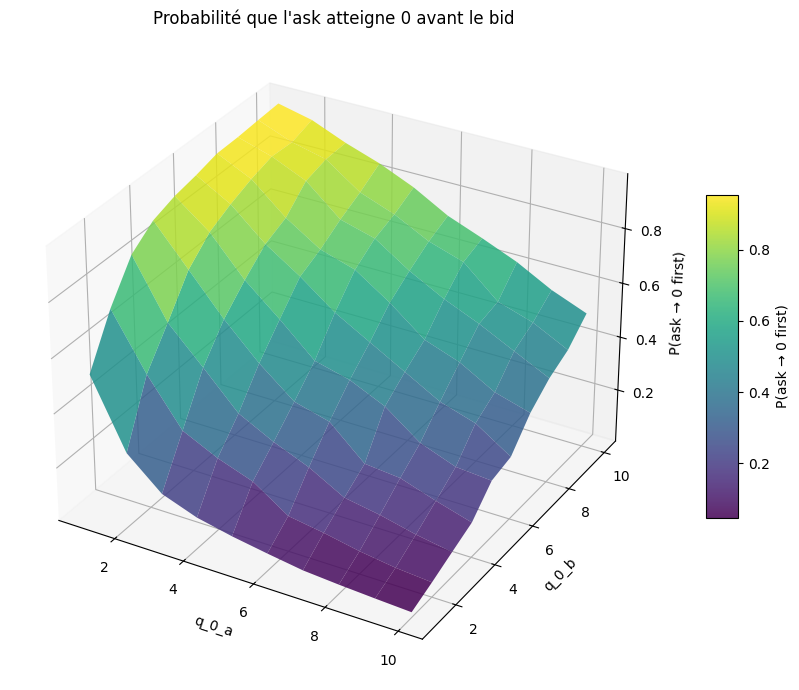

In [58]:
plot_proba_as_a_function_of_initial_conditions(LAMBDA_PLUS, LAMBDA_MINUS)

### Validation : surface MC vs prédiction brownienne pour $\mathbb P(\tau_a<\tau_b)$

Pour évaluer la qualité de l'estimateur MC, on compare la surface empirique à la **prédiction de l'approximation diffusive**. Sous la diffusion, $\tau_a \sim \mathrm{IG}(\mu_a, \lambda_a)$ et $\tau_b \sim \mathrm{IG}(\mu_b, \lambda_b)$ sont indépendants ; on calcule alors numériquement
$$\mathbb P(\tau_a < \tau_b) = \int_0^\infty f_{\tau_a}(t)\,\bigl(1 - F_{\tau_b}(t)\bigr)\,dt$$
par quadrature, et on confronte cette surface théorique à la surface MC. L'écart résiduel mesure conjointement (a) le bruit Monte-Carlo et (b) le biais de l'approximation brownienne sur des entiers petits.

Erreur absolue max  : 0.0451
Erreur absolue moy. : 0.0140
Erreur relative max : 45.190%


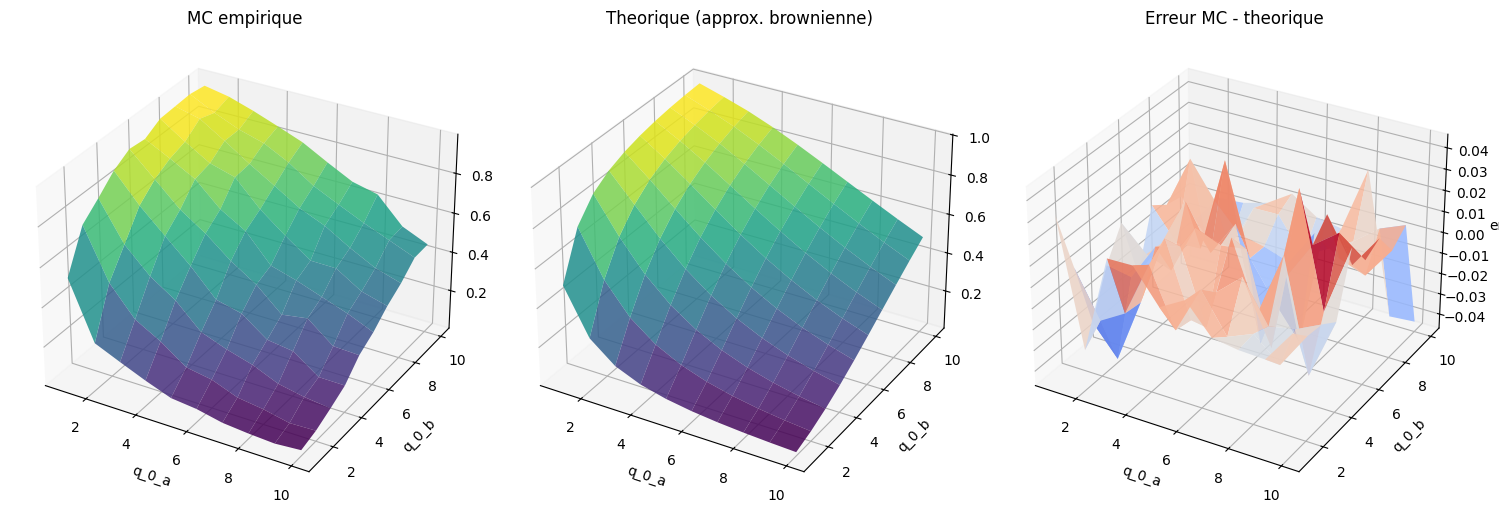

In [59]:
def gamblers_ruin_analytic(q_0_a, q_0_b, lambda_plus, lambda_minus):
    """
    Pour deux marches Bernoulli +1/-1 independantes avec p = lambda^+/(lambda^+ + lambda^-) < 1/2,
    la probabilite que la marche A atteigne 0 avant la marche B (entre A=q_a et B=q_b)
    n'a pas de forme close simple. On utilise donc l'approximation diffusive :
    P(tau_a < tau_b) = P(B^a_{q0_a} < B^b_{q0_b}) ou B^k est inverse-gaussien.
    Pour la version exacte de la marche, on calcule p_k = P(0 atteint avant n par marche
    de pas +1 prob p, -1 prob q=1-p, depart en k) = (r^k - r^n)/(1 - r^n) avec r = p/q,
    et on combine par independance avec la convolution sur le min des deux temps.
    """
    p = lambda_plus / (lambda_plus + lambda_minus)
    q = 1 - p
    r = p / q
    return r, p, q


def validate_gamblers_ruin_via_brownian(lambda_plus, lambda_minus, q_max=10):
    """
    Approximation diffusive : tau_k suit IG(mu_k, lambda_k) avec
       mu_k = k / |drift|, lambda_k = k^2 / sigma^2,  drift = lambda^+ - lambda^-, sigma^2 = lambda^+ + lambda^-.
    Pour deux IG independants on calcule P(tau_a < tau_b) par integration numerique.
    """
    drift = lambda_plus - lambda_minus
    sigma2 = lambda_plus + lambda_minus
    surface = np.zeros((q_max, q_max))
    for i, qa in enumerate(range(1, q_max + 1)):
        for j, qb in enumerate(range(1, q_max + 1)):
            mu_a = qa / abs(drift); shape_a = qa**2 / sigma2
            mu_b = qb / abs(drift); shape_b = qb**2 / sigma2
            # P(tau_a < tau_b) = int_0^inf f_a(t) (1 - F_b(t)) dt
            t_grid = np.linspace(1e-3, max(mu_a, mu_b) * 30, 5000)
            f_a = sps.invgauss.pdf(t_grid, mu=sigma2/(qa*abs(drift)), scale=shape_a)
            S_b = 1 - sps.invgauss.cdf(t_grid, mu=sigma2/(qb*abs(drift)), scale=shape_b)
            surface[j, i] = np.trapezoid(f_a * S_b, t_grid)
    return surface


def compare_proba_surface(lambda_plus, lambda_minus, num_simulations=500, q_max=10):
    surface_mc = np.zeros((q_max, q_max))
    for i, qa in enumerate(range(1, q_max + 1)):
        for j, qb in enumerate(range(1, q_max + 1)):
            surface_mc[j, i] = probability_of_asking_price_reaching_zero_before_bid(
                lambda_plus, lambda_minus, q_0_a=qa, q_0_b=qb, num_simulations=num_simulations
            )
    surface_th = validate_gamblers_ruin_via_brownian(lambda_plus, lambda_minus, q_max=q_max)
    err = surface_mc - surface_th
    abs_err = np.abs(err)

    print(f"Erreur absolue max  : {abs_err.max():.4f}")
    print(f"Erreur absolue moy. : {abs_err.mean():.4f}")
    print(f"Erreur relative max : {(abs_err / np.maximum(surface_th, 1e-3)).max():.3%}")

    fig = plt.figure(figsize=(15, 5))
    Q0_A, Q0_B = np.meshgrid(range(1, q_max + 1), range(1, q_max + 1))
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    ax1.plot_surface(Q0_A, Q0_B, surface_mc, cmap='viridis', alpha=0.85)
    ax1.set_title("MC empirique"); ax1.set_xlabel('q_0_a'); ax1.set_ylabel('q_0_b'); ax1.set_zlabel('P')
    ax2 = fig.add_subplot(1, 3, 2, projection='3d')
    ax2.plot_surface(Q0_A, Q0_B, surface_th, cmap='viridis', alpha=0.85)
    ax2.set_title("Theorique (approx. brownienne)"); ax2.set_xlabel('q_0_a'); ax2.set_ylabel('q_0_b'); ax2.set_zlabel('P')
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    ax3.plot_surface(Q0_A, Q0_B, err, cmap='coolwarm', alpha=0.85)
    ax3.set_title("Erreur MC - theorique"); ax3.set_xlabel('q_0_a'); ax3.set_ylabel('q_0_b'); ax3.set_zlabel('err')
    plt.tight_layout(); plt.show()
    return surface_mc, surface_th


_ = compare_proba_surface(LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=500, q_max=10)

## 7. Surface 3D du temps moyen d'atteinte de 0

Dans le même esprit que la surface précédente $\mathbb{P}(\tau_a < \tau_b)$, on estime maintenant la surface du **temps moyen d'épuisement d'un côté** :
$$T(q_0^a, q_0^b) = \mathbb{E}[\min(\tau_a, \tau_b)],$$
pour chaque couple de conditions initiales $(q_0^a, q_0^b) \in \{1,\dots,q_{\max}\}^2$. La fonction `time_to_zero_surface` calcule simultanément :

- la moyenne empirique sur $M$ simulations,
- les bornes de l'intervalle de confiance asymptotique à 95% ($\hat T \pm z_{0.975}\,\hat\sigma/\sqrt M$),
- la probabilité $\mathbb{P}(\tau_a < \tau_b)$ (réutilisée pour comparaison avec la surface du chapitre 6).

On affiche ensuite les deux surfaces côte à côte, le maillage rouge/noir matérialisant l'intervalle de confiance autour de la surface des temps moyens. La surface $T$ est strictement croissante en chacune des deux variables : un plus gros volume initial repousse le moment d'épuisement.

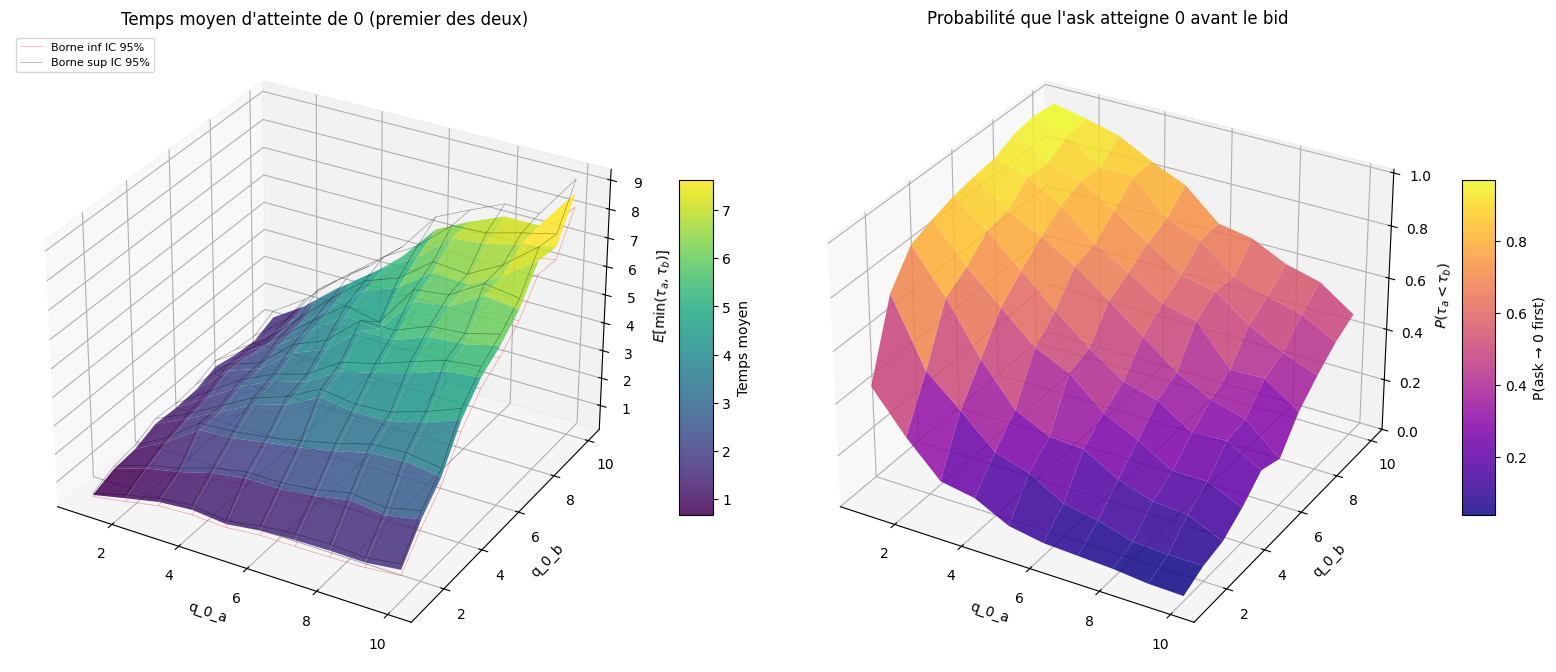

In [60]:
def time_to_zero_surface(lambda_plus, lambda_minus, num_simulations=300, q_max=10, quantile=0.95):
    q_0_values = list(range(1, q_max + 1))
    Q0_A_vals, Q0_B_vals = np.meshgrid(q_0_values, q_0_values)
    mean_times = np.zeros_like(Q0_A_vals, dtype=float)
    lower = np.zeros_like(Q0_A_vals, dtype=float)
    upper = np.zeros_like(Q0_A_vals, dtype=float)
    proba_ask_first = np.zeros_like(Q0_A_vals, dtype=float)
    z = sps.norm.ppf((1 + quantile) / 2)

    for i, q0_a in enumerate(q_0_values):
        for j, q0_b in enumerate(q_0_values):
            samples = np.empty(num_simulations)
            ask_first = 0
            for k in range(num_simulations):
                tb, _, ta, _ = simulate_poisson_process_until_zero(
                    lambda_plus, lambda_minus, q_0_a=q0_a, q_0_b=q0_b
                )
                samples[k] = min(tb[-1], ta[-1])
                if ta[-1] < tb[-1]:
                    ask_first += 1
            m = samples.mean()
            se = samples.std(ddof=1) / np.sqrt(num_simulations)
            mean_times[j, i] = m
            lower[j, i] = m - z * se
            upper[j, i] = m + z * se
            proba_ask_first[j, i] = ask_first / num_simulations

    return Q0_A_vals, Q0_B_vals, mean_times, lower, upper, proba_ask_first


def plot_time_and_probability_surfaces(lambda_plus, lambda_minus, num_simulations=300, q_max=10, quantile=0.95):
    Q0_A, Q0_B, mean_times, lower, upper, proba = time_to_zero_surface(
        lambda_plus, lambda_minus,
        num_simulations=num_simulations, q_max=q_max, quantile=quantile,
    )

    fig = plt.figure(figsize=(16, 7))

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf1 = ax1.plot_surface(Q0_A, Q0_B, mean_times, cmap='viridis', alpha=0.85)
    ax1.plot_wireframe(Q0_A, Q0_B, lower, color='red', alpha=0.35, linewidth=0.5,
                       label=f'Borne inf IC {int(quantile*100)}%')
    ax1.plot_wireframe(Q0_A, Q0_B, upper, color='black', alpha=0.35, linewidth=0.5,
                       label=f'Borne sup IC {int(quantile*100)}%')
    ax1.set_xlabel('q_0_a')
    ax1.set_ylabel('q_0_b')
    ax1.set_zlabel(r'$E[\min(\tau_a, \tau_b)]$')
    ax1.set_title("Temps moyen d'atteinte de 0 (premier des deux)")
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='Temps moyen')
    ax1.legend(loc='upper left', fontsize=8)

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf2 = ax2.plot_surface(Q0_A, Q0_B, proba, cmap='plasma', alpha=0.85)
    ax2.set_xlabel('q_0_a')
    ax2.set_ylabel('q_0_b')
    ax2.set_zlabel(r'$P(\tau_a < \tau_b)$')
    ax2.set_title("Probabilité que l'ask atteigne 0 avant le bid")
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='P(ask → 0 first)')

    plt.tight_layout()
    plt.show()

    return mean_times, lower, upper, proba


_ = plot_time_and_probability_surfaces(
    LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=300, q_max=10, quantile=0.95
)

## 8. Modèle de Hawkes : intensité auto-excitée

On enrichit le modèle en remplaçant l'intensité constante $\lambda^-$ par une **intensité de Hawkes** auto-excitée :

$$\lambda^-(t) = \mu^- + \sum_{T_i < t} \alpha\, e^{-\beta(t - T_i)},$$

où les $T_i$ sont les temps de saut. Chaque événement augmente instantanément l'intensité de $\alpha$ ; entre deux événements, $\lambda^-$ relaxe exponentiellement vers la valeur de fond $\mu^-$ à un taux $\beta$.

**Stationnarité.** En régime stationnaire, l'intensité moyenne $\bar\lambda^-$ vérifie
$$\bar\lambda^- = \mu^- + \frac{\alpha}{\beta}\,\bar\lambda^-,$$
ce qui donne une intensité moyenne finie ssi $\alpha < \beta$. La fonction `determine_lambda_minus_stationarity` calcule la valeur stationnaire prédite à partir des paramètres.

In [61]:
def determine_lambda_minus_stationarity(mu_minus, alpha, beta, lambda_plus=LAMBDA_PLUS):
    return (mu_minus * beta - lambda_plus * alpha) / (beta - alpha)

## 9. Simulation par algorithme de thinning d'Ogata

L'intensité $\lambda^-(t)$ est non bornée a priori, mais bornée par morceaux entre deux événements (elle décroît exponentiellement). On simule donc le processus par l'**algorithme de thinning d'Ogata** :

1. Entre deux événements, on majore $\lambda^-(t)$ par $\bar\lambda = \max(\mu^-, \lambda^-(t_{\text{last}}))$.
2. On échantillonne un candidat exponentiel de paramètre $\bar\lambda + \lambda^+$.
3. Au candidat $t'$, on calcule la valeur effective $\lambda^-(t') = \mu^- + (\lambda^-_{t_{\text{last}}} - \mu^-)e^{-\beta(t' - t_{\text{last}})}$.
4. Avec un tirage uniforme on accepte/rejette : on accepte un saut $+1$ avec probabilité $\lambda^+/(\bar\lambda + \lambda^+)$, un saut $-1$ avec probabilité $\lambda^-(t')/(\bar\lambda + \lambda^+)$, sinon on rejette et on relaxe l'intensité.

Lors d'un événement effectif, on met à jour $\lambda^-$ par un saut $\pm \alpha$ selon le signe du saut sur $q$.

In [62]:
def hawkes_simulation(mu_minus, alpha, beta,lambda_plus = LAMBDA_PLUS, q_0 = Q_0, stopping_condition=lambda q,t: t > T):
    q = q_0
    t = 0
    t_last = 0
    lambda_bar = mu_minus
    lambda_minus_t = mu_minus
    lambda_minus_list = [lambda_minus_t]
    times = [t]
    q_values = [q]
    while not stopping_condition(q, t):
        lambda_bar = max(mu_minus, lambda_minus_t)
        sup_lambda = lambda_bar + lambda_plus
        time_to_next_event = np.random.exponential(1 / sup_lambda)
        t_prime = t + time_to_next_event
        lambda_pre = mu_minus + (lambda_minus_t - mu_minus) * np.exp(-beta * (t_prime - t_last))
        lambda_eff = max(lambda_pre, 0)
        U = np.random.rand()
        if U < lambda_plus / sup_lambda:
            q += 1
            t = t_prime
            t_last = t
            lambda_minus_t = lambda_pre - alpha
            times.append(t)
            q_values.append(q)
            lambda_minus_list.append(lambda_minus_t)
        elif U < (lambda_eff+lambda_plus) / sup_lambda:
            q -= 1
            t = t_prime
            t_last = t
            lambda_minus_t = lambda_pre + alpha
            times.append(t)
            q_values.append(q)
            lambda_minus_list.append(lambda_minus_t)
        else:
            lambda_minus_t = lambda_pre
            t_last = t_prime
            t = t_prime
        
    return times, q_values, lambda_minus_list

def plot_hawkes_process(times, q_values):
    plt.figure(figsize=(12, 6))
    plt.step(times, q_values, where='post')
    plt.title('Évolution de q au fil du temps (Hawkes)')
    plt.xlabel('Temps')
    plt.ylabel('q')
    plt.grid()
    plt.show()
    
def distribution_of_stopping_times_hawkes(mu_minus, alpha, beta, lambda_plus=LAMBDA_PLUS, q_0=Q_0, num_simulations=1000):
    stopping_times = []
    for _ in range(num_simulations):
        times, _, _ = hawkes_simulation(mu_minus, alpha, beta, lambda_plus, q_0=q_0, stopping_condition=lambda q,t: q == 0)
        stopping_times.append(times[-1])
    plt.figure(figsize=(10, 6))
    plt.hist(stopping_times, bins='auto', density=True, alpha=0.6, color='c', label='Simulation Hawkes')
    plt.xlabel("Temps jusqu'à ce que q atteigne zéro (Hawkes)")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'arrêt pour le processus Hawkes")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
def plot_lambda_minus_over_time(times, lambda_minus_list):
    plt.figure(figsize=(12, 6))
    plt.step(times, lambda_minus_list, where='post')
    plt.title('Évolution de λ⁻ au fil du temps (Hawkes)')
    plt.xlabel('Temps')
    plt.ylabel('λ⁻(t)')
    plt.grid()
    plt.show()

def distribution_last_lambda_minus(T=T, num_simulations=1000, mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS, q_0=Q_0):
    stationnary_lambda_minus = determine_lambda_minus_stationarity(mu_minus, alpha, beta, lambda_plus)
    last_lambda_minus_values = []
    for _ in range(num_simulations):
        times, _, lambda_minus_list = hawkes_simulation(mu_minus, alpha, beta, lambda_plus, q_0=q_0, stopping_condition=lambda q,t: t > T)
        times_arr = np.array(times)
        idx = np.searchsorted(times_arr, T, side='right') - 1
        lambda_at_T = mu_minus + (lambda_minus_list[idx] - mu_minus) * np.exp(-beta * (T - times[idx]))
        last_lambda_minus_values.append(lambda_at_T)
    plt.figure(figsize=(10, 6))
    plt.hist(last_lambda_minus_values, bins='auto', density=True, alpha=0.6, color='m', label='Simulation Hawkes')
    plt.xlabel("Valeur de λ⁻ à l'instant T")
    plt.ylabel('Densité')
    plt.title("Distribution de λ⁻ à l'instant T pour le processus Hawkes")
    plt.axvline(stationnary_lambda_minus, color='r', linestyle='--', label=f'λ⁻ stationnaire ≈ {stationnary_lambda_minus:.2f}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    

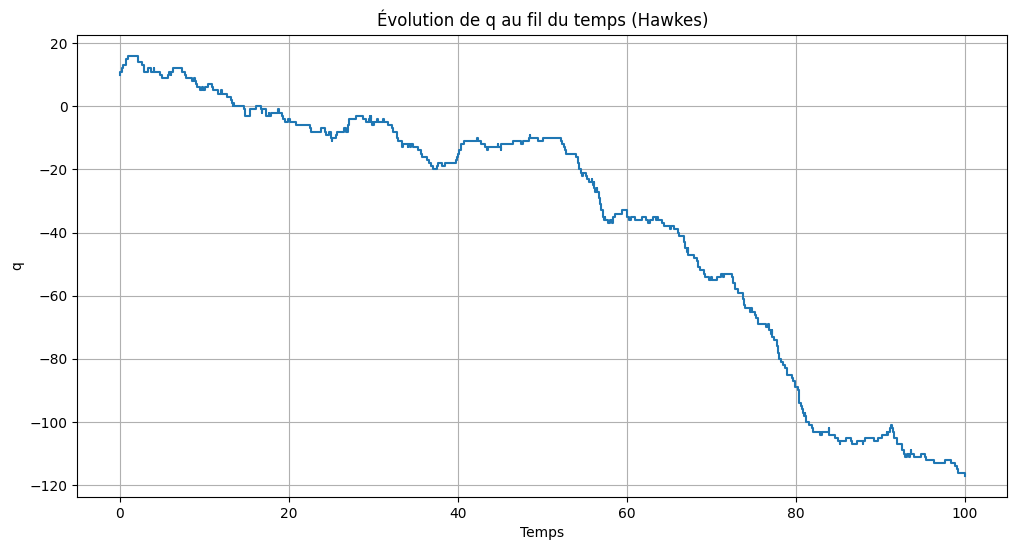

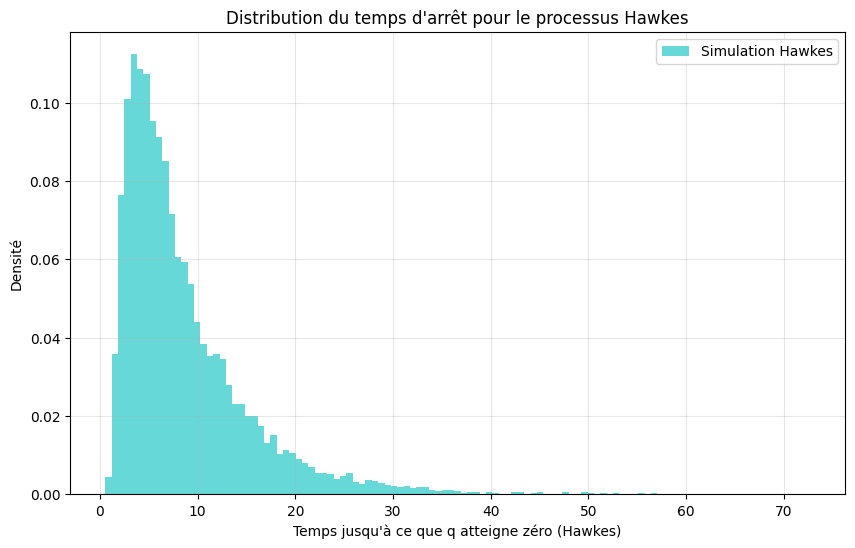

In [63]:
times, q_values, lambda_minus_list = hawkes_simulation(mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS, q_0=Q_0, stopping_condition=lambda q,t: t > T)
plot_hawkes_process(times, q_values)
distribution_of_stopping_times_hawkes (mu_minus=2, alpha=0.5, beta=1, num_simulations=10000)


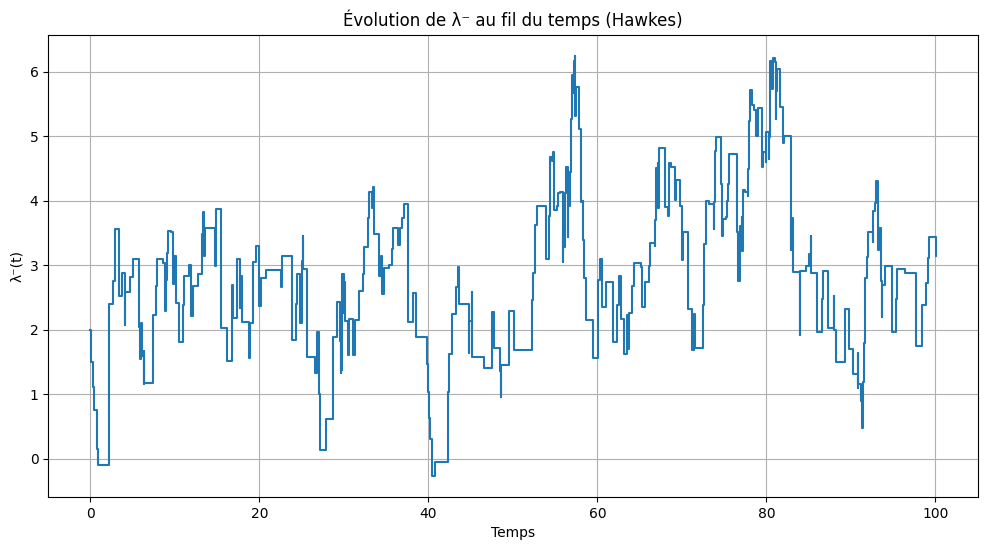

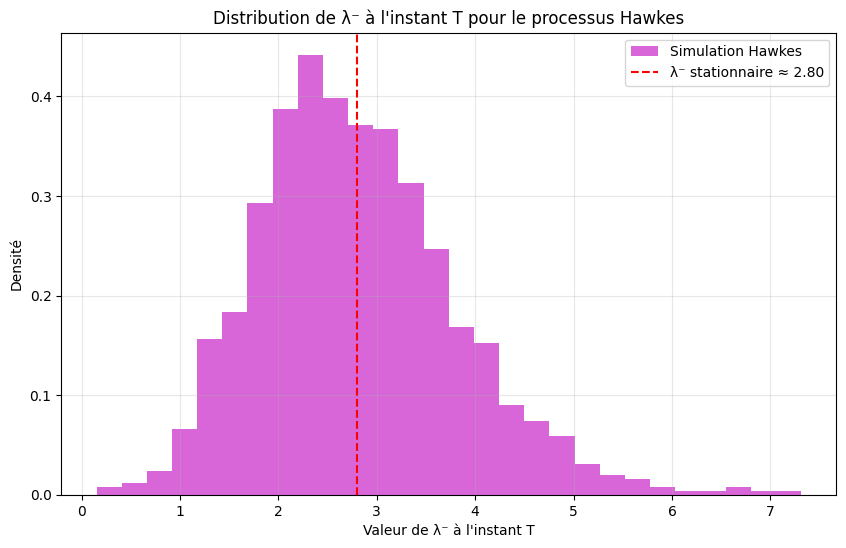

In [64]:
plot_lambda_minus_over_time(times, lambda_minus_list)
distribution_last_lambda_minus(T=1000, num_simulations=1000, mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS, q_0=Q_0)

### Validation : moyenne stationnaire de $\lambda^-$

Le calcul de point fixe donne, pour le Hawkes ouvert sur les sauts $\pm 1$ symétriques autour de $\mu^-$ :
$$\bar\lambda^-_\infty = \frac{\mu^-\beta - \lambda^+\alpha}{\beta - \alpha}.$$
Avec $\mu^-=2,\ \alpha=0.5,\ \beta=1,\ \lambda^+=1.2$ on attend $\bar\lambda^-_\infty = 2.8$.

On le vérifie en simulant $N$ trajectoires longues ($T=2000$) avec $q_0$ très grand (pour ne pas s'arrêter en 0), en jetant un *burn-in* initial pour éliminer le transitoire, puis en calculant la **moyenne temporelle** de $\lambda^-(t)$ sur chaque trajectoire. La moyenne d'ensemble doit être proche de la valeur théorique.

In [65]:
def validate_stationary_lambda_minus(mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS,
                                     T_long=2000, num_simulations=200, burn_in=200):
    theoretical = determine_lambda_minus_stationarity(mu_minus, alpha, beta, lambda_plus)
    empirical_means = []
    for _ in range(num_simulations):
        times, _, lambda_minus_list = hawkes_simulation(
            mu_minus, alpha, beta, lambda_plus, q_0=10**6,
            stopping_condition=lambda q, t: t > T_long,
        )
        times_arr = np.asarray(times)
        lam_arr = np.asarray(lambda_minus_list)
        mask = times_arr >= burn_in
        if mask.sum() < 2:
            continue
        t_kept = times_arr[mask]
        lam_kept = lam_arr[mask]
        dt = np.diff(t_kept)
        time_avg = np.sum(lam_kept[:-1] * dt) / (t_kept[-1] - t_kept[0])
        empirical_means.append(time_avg)

    empirical_means = np.array(empirical_means)
    mean_emp = empirical_means.mean()
    std_emp = empirical_means.std(ddof=1)
    se = std_emp / np.sqrt(len(empirical_means))
    z = sps.norm.ppf(0.975)
    print(f"Valeur theorique stationnaire de lambda^- : {theoretical:.4f}")
    print(f"Moyenne empirique (n={len(empirical_means)} trajectoires, T={T_long}, burn-in={burn_in}) : "
          f"{mean_emp:.4f} +/- {z*se:.4f} (IC 95%)")
    print(f"Ecart relatif : {100*(mean_emp - theoretical)/theoretical:+.2f} %")
    return theoretical, mean_emp, se


_ = validate_stationary_lambda_minus(mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS,
                                     T_long=2000, num_simulations=100, burn_in=200)

Valeur theorique stationnaire de lambda^- : 2.8000
Moyenne empirique (n=100 trajectoires, T=2000, burn-in=200) : 2.9676 +/- 0.0107 (IC 95%)
Ecart relatif : +5.99 %


## 10. Processus de Hawkes couplés (Bid / Ask)

On introduit deux files (bid et ask) avec leurs intensités propres $\lambda^-_a$ et $\lambda^-_b$, **mutuellement excitées** : un événement sur l'ask diminue l'intensité côté ask et augmente celle côté bid (et réciproquement). Cela modélise grossièrement la propagation d'un déséquilibre — quand un côté du carnet se vide, la pression de marché s'accumule de l'autre côté.

$$
\lambda^-_a(t) = \mu^-_a + \sum_{T_i^a < t} \alpha_a^{ii}\, e^{-\beta(t - T_i^a)} + \sum_{T_j^b < t} \alpha_a^{ij}\, e^{-\beta(t - T_j^b)}, \qquad \text{(idem pour } \lambda^-_b\text{)}.
$$

Sur le plan algorithmique, on combine un thinning d'Ogata global (avec borne $\bar\lambda_a + \bar\lambda_b + \lambda^+_a + \lambda^+_b$) et la mise à jour conjointe des deux intensités à chaque événement.

In [66]:
def simulated_coupled_hawkes_processes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B):
    q_a = q_0_a
    q_b = q_0_b
    t = 0
    t_last_a = 0
    t_last_b = 0
    lambda_bar_a = mu_minus_a
    lambda_bar_b = mu_minus_b
    lambda_minus_a_t = mu_minus_a
    lambda_minus_b_t = mu_minus_b
    times = [t]
    times_a = [t]
    times_b = [t]
    q_a_values = [q_a]
    q_b_values = [q_b]
    while q_a > 0 and q_b > 0:
        lambda_bar_a = max(mu_minus_a, lambda_minus_a_t)
        lambda_bar_b = max(mu_minus_b, lambda_minus_b_t)
        sup_lambda = lambda_bar_a + lambda_bar_b + lambda_plus_a + lambda_plus_b
        time_to_next_event = np.random.exponential(1 / sup_lambda)
        t_prime = t + time_to_next_event
        lambda_pre_a = mu_minus_a + (lambda_minus_a_t - mu_minus_a) * np.exp(-beta * (t_prime - t_last_a))
        lambda_pre_b = mu_minus_b + (lambda_minus_b_t - mu_minus_b) * np.exp(-beta * (t_prime - t_last_b))
        lambda_eff_a = max(lambda_pre_a, 0)
        lambda_eff_b = max(lambda_pre_b, 0)
        U = np.random.rand()
        if U < lambda_plus_a / sup_lambda:
            q_a += 1
            t = t_prime
            t_last_a = t
            lambda_minus_a_t = lambda_pre_a - alpha
            lambda_minus_b_t = lambda_pre_b + alpha
            times.append(t)
            times_a.append(t)
            q_a_values.append(q_a)
        elif U < (lambda_eff_a+lambda_plus_a) / sup_lambda:
            q_a -= 1
            t = t_prime
            t_last_a = t
            lambda_minus_a_t = lambda_pre_a + alpha
            lambda_minus_b_t = lambda_pre_b - alpha
            times.append(t)
            times_a.append(t)   
            q_a_values.append(q_a)
        elif U < (lambda_bar_a+lambda_plus_a) / sup_lambda:
            lambda_minus_a_t = lambda_pre_a
            lambda_minus_b_t = lambda_pre_b
            t_last_a = t_prime
            t = t_prime
        elif U < (lambda_bar_a+lambda_plus_a+lambda_plus_b) / sup_lambda:
            q_b += 1
            t = t_prime
            t_last_b = t
            lambda_minus_b_t = lambda_pre_b - alpha
            lambda_minus_a_t = lambda_pre_a + alpha
            times.append(t)
            times_b.append(t)
            q_b_values.append(q_b)
        elif U < (lambda_bar_a+lambda_plus_a+lambda_eff_b+lambda_plus_b) / sup_lambda:
            q_b -= 1
            t = t_prime
            t_last_b = t
            lambda_minus_b_t = lambda_pre_b + alpha
            lambda_minus_a_t = lambda_pre_a - alpha
            times.append(t)
            times_b.append(t)
            q_b_values.append(q_b)
        else:
            lambda_minus_b_t = lambda_pre_b
            lambda_minus_a_t = lambda_pre_a
            t_last_b = t_prime
            t = t_prime
    return times, times_a, times_b, q_a_values, q_b_values


def plot_coupled_hawkes_process(times, times_a, times_b, q_a_values, q_b_values):
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.step(times_a, q_a_values, where='post')
    plt.title('Évolution de q_a au fil du temps (Hawkes couplé)')
    plt.xlabel('Temps')
    plt.ylabel('q_a')
    plt.grid()
    plt.subplot(2, 1, 2)
    plt.step(times_b, q_b_values, where='post')
    plt.title('Évolution de q_b au fil du temps (Hawkes couplé)')
    plt.xlabel('Temps')
    plt.ylabel('q_b')
    plt.tight_layout()
    plt.grid()
    plt.show()
    
def plot_stopping_time_distribution_coupled_hawkes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B, num_simulations=1000):
    stopping_times = []
    for _ in range(num_simulations):
        times,_ ,_ , _, _ = simulated_coupled_hawkes_processes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
        stopping_times.append(times[-1])
    plt.figure(figsize=(10, 6))
    plt.hist(stopping_times, bins='auto', density=True, alpha=0.6, color='purple', label='Simulation Hawkes couplé')
    plt.xlabel("Temps jusqu'à ce que q_a ou q_b atteigne zéro (Hawkes couplé)")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'arrêt pour les processus Hawkes couplés")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

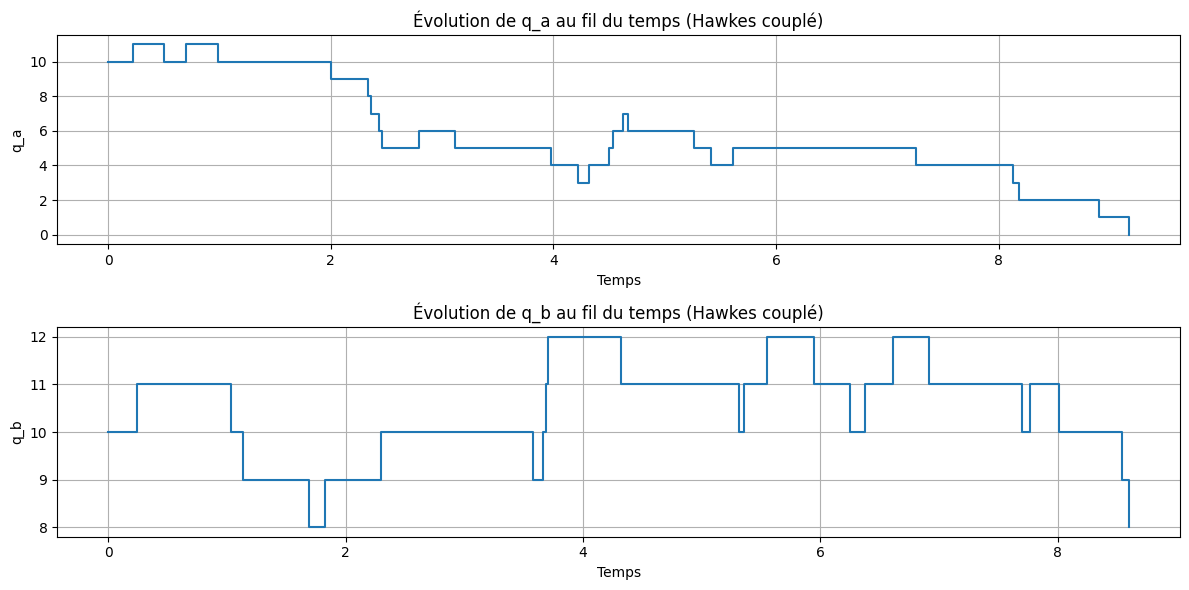

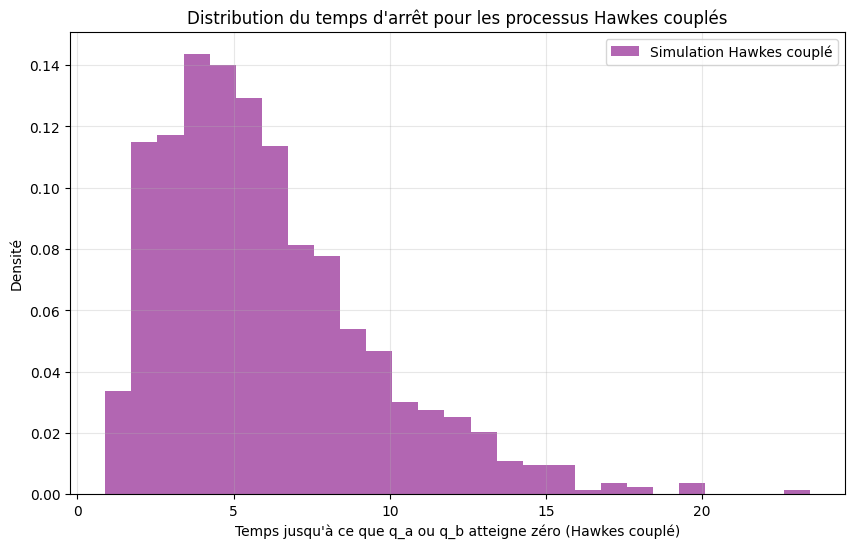

In [67]:
times,times_a, times_b, q_a_values, q_b_values = simulated_coupled_hawkes_processes(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B)
plot_coupled_hawkes_process(times, times_a, times_b, q_a_values, q_b_values)
plot_stopping_time_distribution_coupled_hawkes(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B)

### Surfaces 3D pour le processus de Hawkes couplé

On reproduit ici les deux surfaces 3D estimées à la section §7 (cas Poisson indépendant), mais cette fois sous le **modèle de Hawkes couplé** introduit ci-dessus. Sur la grille $(q_0^a, q_0^b) \in \{1,\dots,q_{\max}\}^2$, on estime par Monte-Carlo :

- $T(q_0^a, q_0^b) = \mathbb{E}[\min(\tau_a, \tau_b)]$ — temps moyen avant qu'un côté ne s'épuise,
- $p(q_0^a, q_0^b) = \mathbb{P}(\tau_a < \tau_b)$ — probabilité que l'ask cède en premier,

avec leurs intervalles de confiance asymptotiques à 95% (matérialisés par les wireframes rouge/noir autour de la surface des temps moyens).

**Différence majeure avec le cas Poisson.** Contrairement à la ruine du gambler dans le cas Poisson indépendant, il n'existe pas ici de formule analytique simple : le couplage entre $\lambda^-_a$ et $\lambda^-_b$ rend le système non-Markovien dans $(q_a, q_b)$ seul (il faut adjoindre l'état des intensités $(\lambda^-_a, \lambda^-_b)$). Le Monte-Carlo reste cependant valide.

**Lectures attendues des surfaces.**

- Lorsque $\mu^-_a = \mu^-_b$ (cas symétrique), la surface $p$ doit être symétrique le long de la diagonale $q_0^a = q_0^b$, et $p \approx 1/2$ sur cette diagonale.
- Pour des paramètres asymétriques ($\mu^-_a \neq \mu^-_b$), la surface $p$ s'écarte de la diagonale, traduisant un côté plus fragile.
- L'**auto-excitation** ($\alpha > 0$) tend à raccourcir $T$ par rapport au cas Poisson, un phénomène déjà visible dans la comparaison de la section §11.

⚠️ La simulation de Hawkes couplés étant nettement plus coûteuse que celle des Poisson indépendants (thinning d'Ogata global avec mises à jour des deux intensités à chaque itération), on prend `num_simulations=200` par défaut au lieu de 300.

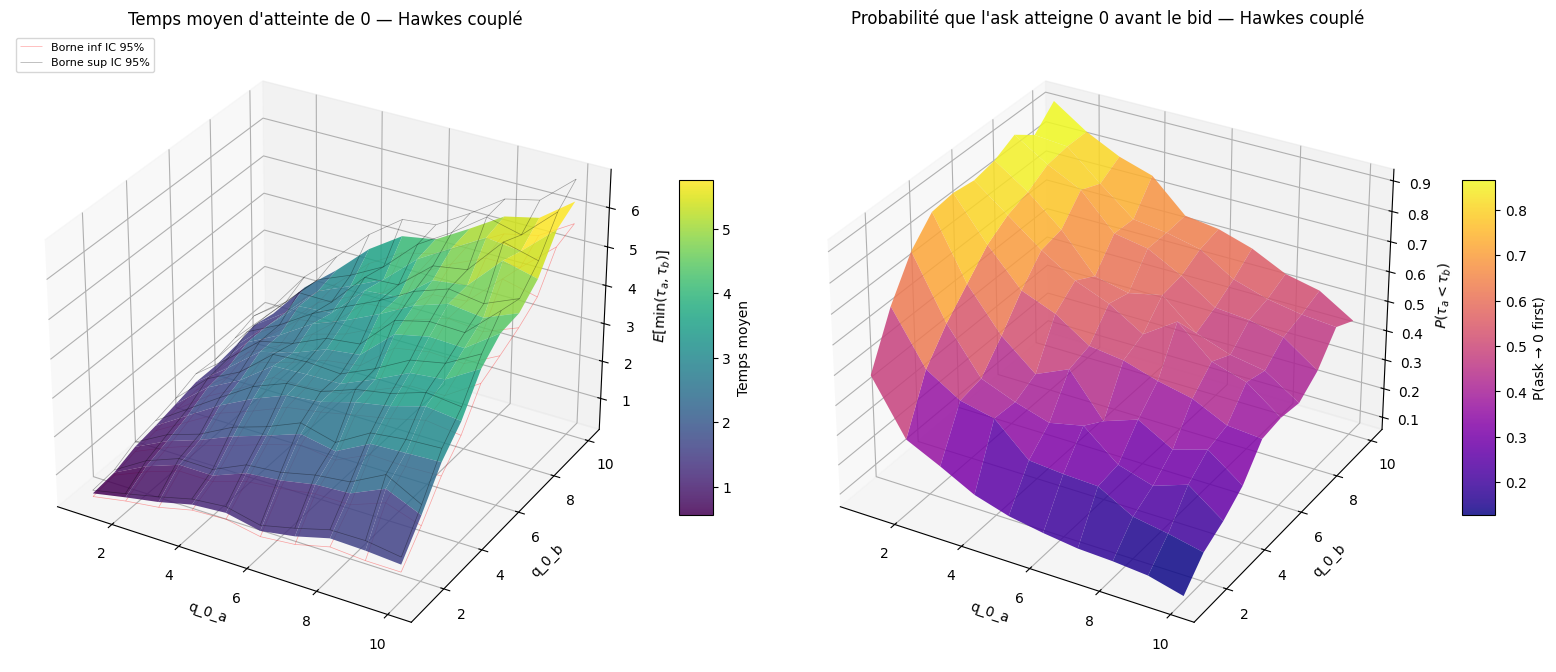

In [68]:
def coupled_hawkes_surface(mu_minus_a, mu_minus_b, alpha, beta,
                           lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                           num_simulations=200, q_max=10, quantile=0.95):
    q_0_values = list(range(1, q_max + 1))
    Q0_A_vals, Q0_B_vals = np.meshgrid(q_0_values, q_0_values)
    mean_times = np.zeros_like(Q0_A_vals, dtype=float)
    lower = np.zeros_like(Q0_A_vals, dtype=float)
    upper = np.zeros_like(Q0_A_vals, dtype=float)
    proba_ask_first = np.zeros_like(Q0_A_vals, dtype=float)
    z = sps.norm.ppf((1 + quantile) / 2)

    for i, q0_a in enumerate(q_0_values):
        for j, q0_b in enumerate(q_0_values):
            samples = np.empty(num_simulations)
            ask_first = 0
            for k in range(num_simulations):
                times, _, _, q_a_values, q_b_values = simulated_coupled_hawkes_processes(
                    mu_minus_a, mu_minus_b, alpha, beta,
                    lambda_plus_a=lambda_plus_a, lambda_plus_b=lambda_plus_b,
                    q_0_a=q0_a, q_0_b=q0_b,
                )
                samples[k] = times[-1]
                if q_a_values[-1] == 0:
                    ask_first += 1
            m = samples.mean()
            se = samples.std(ddof=1) / np.sqrt(num_simulations)
            mean_times[j, i] = m
            lower[j, i] = m - z * se
            upper[j, i] = m + z * se
            proba_ask_first[j, i] = ask_first / num_simulations

    return Q0_A_vals, Q0_B_vals, mean_times, lower, upper, proba_ask_first


def plot_coupled_hawkes_surfaces(mu_minus_a, mu_minus_b, alpha, beta,
                                 lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                                 num_simulations=200, q_max=10, quantile=0.95):
    Q0_A, Q0_B, mean_times, lower, upper, proba = coupled_hawkes_surface(
        mu_minus_a, mu_minus_b, alpha, beta,
        lambda_plus_a=lambda_plus_a, lambda_plus_b=lambda_plus_b,
        num_simulations=num_simulations, q_max=q_max, quantile=quantile,
    )

    fig = plt.figure(figsize=(16, 7))

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf1 = ax1.plot_surface(Q0_A, Q0_B, mean_times, cmap='viridis', alpha=0.85)
    ax1.plot_wireframe(Q0_A, Q0_B, lower, color='red', alpha=0.35, linewidth=0.5,
                       label=f'Borne inf IC {int(quantile*100)}%')
    ax1.plot_wireframe(Q0_A, Q0_B, upper, color='black', alpha=0.35, linewidth=0.5,
                       label=f'Borne sup IC {int(quantile*100)}%')
    ax1.set_xlabel('q_0_a')
    ax1.set_ylabel('q_0_b')
    ax1.set_zlabel(r'$E[\min(\tau_a, \tau_b)]$')
    ax1.set_title("Temps moyen d'atteinte de 0 — Hawkes couplé")
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='Temps moyen')
    ax1.legend(loc='upper left', fontsize=8)

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf2 = ax2.plot_surface(Q0_A, Q0_B, proba, cmap='plasma', alpha=0.85)
    ax2.set_xlabel('q_0_a')
    ax2.set_ylabel('q_0_b')
    ax2.set_zlabel(r'$P(\tau_a < \tau_b)$')
    ax2.set_title("Probabilité que l'ask atteigne 0 avant le bid — Hawkes couplé")
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='P(ask → 0 first)')

    plt.tight_layout()
    plt.show()

    return mean_times, lower, upper, proba


_ = plot_coupled_hawkes_surfaces(
    mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1,
    lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
    num_simulations=200, q_max=10, quantile=0.95,
)

## 11. Comparaison des distributions de temps d'arrêt

On compare les distributions du temps d'atteinte de 0 obtenues sous différents modèles : Poisson seul, premier de deux Poisson indépendants, Hawkes seul, et Hawkes couplé. On visualise ainsi l'impact respectif :

- du **second processus** (passage à $\min(\tau_a,\tau_b)$, qui réduit mécaniquement le temps d'arrêt),
- de l'**auto-excitation** (queues plus lourdes, variance plus grande),
- du **couplage** entre les deux files (asymétrie systématique entre les côtés bid et ask).

In [69]:
#comparing all different stopping times from individual poisson, first of two poisson, hawkes and coupled hawkes
def compare_stopping_time_distributions(mu_minus, alpha, beta, lambda_plus=LAMBDA_PLUS, q_0=Q_0, num_simulations=1000):
    stopping_times_poisson = []
    stopping_times_first_of_two = []
    stopping_times_hawkes = []
    stopping_times_coupled_hawkes = []
    
    for _ in range(num_simulations):
        # Poisson
        times, _ = simulate_only_one_process(lambda_plus, mu_minus, q_0)
        stopping_times_poisson.append(times[-1])
        
        # First of two Poisson
        times_b, _, times_a, _ = simulate_poisson_process_until_zero(lambda_plus, mu_minus, q_0_a=q_0, q_0_b=q_0)
        stopping_times_first_of_two.append(min(times_b[-1], times_a[-1]))
        
        # Hawkes
        times_hawkes, _, _ = hawkes_simulation(mu_minus, alpha, beta, lambda_plus, q_0=q_0, stopping_condition=lambda q,t: q == 0)
        stopping_times_hawkes.append(times_hawkes[-1])
        
        # Coupled Hawkes
        times_coupled_hawkes, _, _, _, _ = simulated_coupled_hawkes_processes(mu_minus, mu_minus, alpha, beta, lambda_plus, lambda_plus, q_0, q_0)
        stopping_times_coupled_hawkes.append(times_coupled_hawkes[-1])
    
    plt.figure(figsize=(12, 8))
    plt.hist(stopping_times_poisson, bins='auto', density=True, alpha=0.6, color='b', label='Poisson individuel')
    plt.hist(stopping_times_first_of_two, bins='auto', density=True, alpha=0.6, color='g', label='Premier des deux Poisson')
    plt.hist(stopping_times_hawkes, bins='auto', density=True, alpha=0.6, color='r', label='Hawkes')
    plt.hist(stopping_times_coupled_hawkes, bins='auto', density=True, alpha=0.6, color='purple', label='Hawkes couplé')
    plt.xlabel("Temps jusqu'à ce que q atteigne zéro")
    plt.ylabel('Densité')
    plt.title("Comparaison des distributions du temps d'arrêt")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

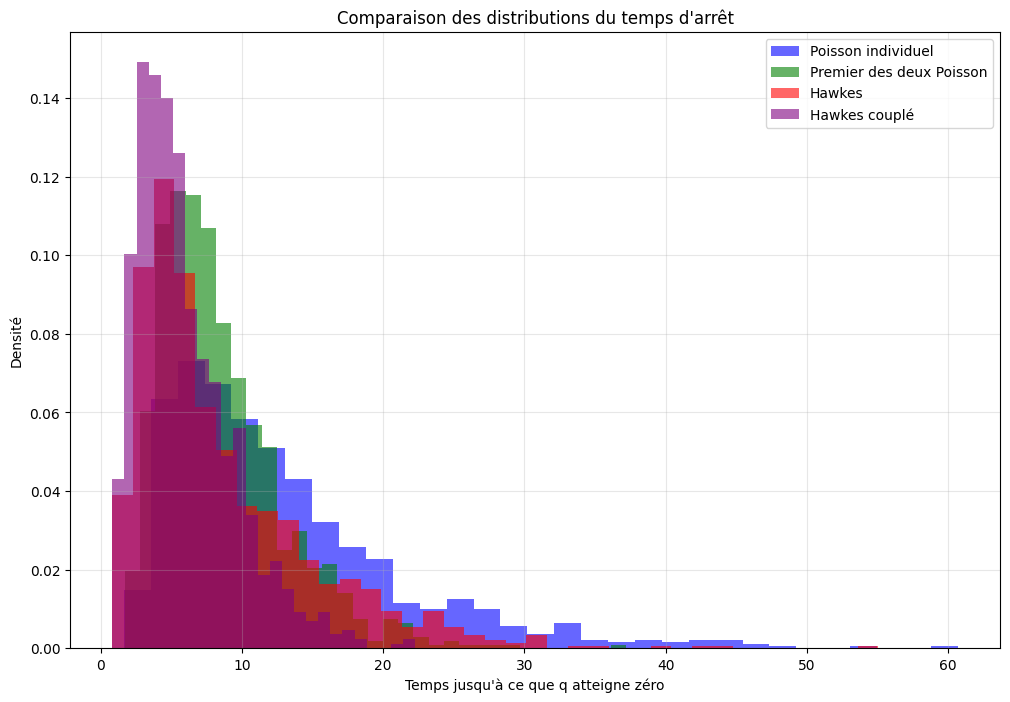

In [70]:
compare_stopping_time_distributions(mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS, q_0=Q_0, num_simulations=1000)

## 12. Distribution conditionnelle d'un processus auxiliaire $q_2$

On considère un troisième processus $q_2$ représentant un autre niveau du carnet, modélisé pour l'instant comme un processus de Poisson de paramètres $(\lambda^+_2, \lambda^-_2)$ simulé en parallèle des deux files Hawkes couplées. On étudie la **loi conditionnelle** de $q_2(\tau)$ sachant l'événement déclenchant $\tau$ :

- soit l'**ask** atteint 0 en premier ($\tau = \tau_a$),
- soit le **bid** atteint 0 en premier ($\tau = \tau_b$).

Cela permet d'estimer empiriquement la distribution de la profondeur restante au niveau adjacent au moment de l'épuisement d'un côté du meilleur niveau, donnée utile pour estimer le coût d'impact d'une exécution agressive.

In [71]:
def simulate_second_limit_distribution(mu_minus_a, mu_minus_b, alpha, beta,lambda_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2, q_0_2=Q_0_2, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B, num_desired=1000):
    count_ask = 0
    count_bid = 0
    q_2_given_ask = []
    times_2_given_ask = []
    q2_given_bid = []
    times_2_given_bid = []
    while count_ask < num_desired or count_bid < num_desired:
        times, times_a, times_b, q_a_values, q_b_values = simulated_coupled_hawkes_processes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a=lambda_plus_a, lambda_plus_b=lambda_plus_b, q_0_a=q_0_a, q_0_b=q_0_b)
        times_2, q_2_values = simulate_only_one_process(lambda_plus_2, lambda_minus_2, q_0_2, stopping_condition=lambda q,t: t < times[-1])
        if q_a_values[-1] == 0:
            count_ask += 1
            q_2_given_ask.append(q_2_values[-1])
            times_2_given_ask.append(times[-1])
        else:
            count_bid += 1
            q2_given_bid.append(q_2_values[-1])
            times_2_given_bid.append(times[-1])
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(q_2_given_ask, bins='auto', density=True, alpha=0.6, color='c', label='q_2 donné ask → 0')
    plt.xlabel("Valeur de q_2 à l'instant où ask atteint zéro")
    plt.ylabel('Densité')
    plt.title("Distribution de q_2 conditionnée à ask → 0")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.hist(q2_given_bid, bins='auto', density=True, alpha=0.6, color='m', label='q_2 donné bid → 0')
    plt.xlabel("Valeur de q_2 à l'instant où bid atteint zéro")
    plt.ylabel('Densité')
    plt.title("Distribution de q_2 conditionnée à bid → 0")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

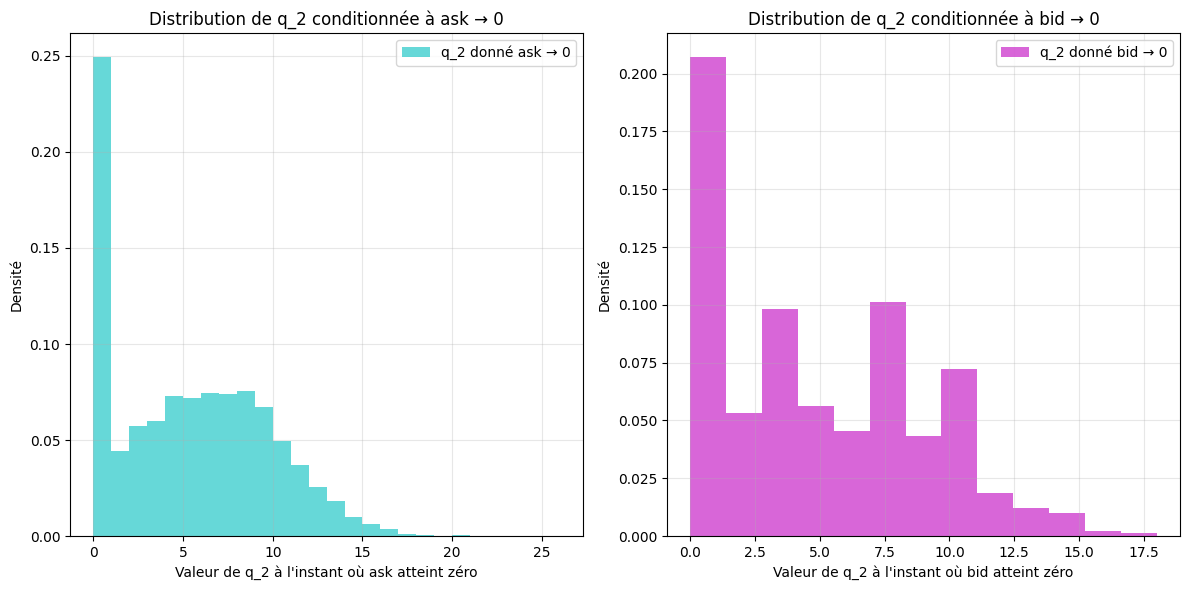

In [72]:
simulate_second_limit_distribution(mu_minus_a=2, mu_minus_b=1.2, alpha=0.5, beta=1, lambda_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2, q_0_2=Q_0_2, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B, num_desired=1000)

## 13. Intensité de $q_2$ excitée par les décréments de l'ask

On raffine le modèle précédent en couplant l'intensité $\lambda^+_2$ du processus auxiliaire au flux d'**événements décrémentant l'ask** : chaque baisse de l'ask augmente instantanément $\lambda^+_2$ d'un saut $a$, qui décroît ensuite exponentiellement au taux $b$. Cela traduit l'idée qu'une consommation rapide d'un niveau d'ask accroît la probabilité d'apparition de nouveaux ordres au niveau adjacent.

$$\lambda^+_2(t) = \mu^+_2 + \sum_{T_i^{\downarrow,a} < t} a\, e^{-b(t - T_i^{\downarrow,a})}.$$

La simulation utilise à nouveau un thinning d'Ogata, en majorant $\lambda^+_2$ par $\mu^+_2 + a \times (\text{nombre total de baisses d'ask sur le run de référence})$ et en filtrant par la valeur effective au candidat. On compare ensuite la distribution conditionnelle obtenue à celle du modèle à intensité constante.

In [73]:
def lambda_plus_ask_2(t, times_ask_decr, a , b, mu_plus_ask_2):
    lambda_plus_2_t = mu_plus_ask_2
    for t_i in times_ask_decr:
        if t_i < t:
            lambda_plus_2_t += a * np.exp(-b * (t - t_i))
    return lambda_plus_2_t

def simulate_only_one_process_with_varying_intensity(jump_times, a,lambda_plus_func, lambda_minus, q_0=Q_0_2, stopping_condition=lambda q,t: t > T):
    q = q_0
    t = 0
    times = [t]
    q_values = [q]
    lambda_bar_plus = lambda_plus_func(0) + a*len(jump_times)
    total_rate = lambda_bar_plus + lambda_minus
    while stopping_condition(q, t):
        lambda_plus_t = lambda_plus_func(t)
        time_to_next_event = np.random.exponential(1 / total_rate)
        t += time_to_next_event
        U = np.random.rand()
        if U < lambda_plus_t / total_rate:
            q += 1
            q = max(q, 0)
            times.append(t)
            q_values.append(q)
        else :
            if U < (lambda_plus_t + lambda_minus) / total_rate:
                q -= 1
                q = max(q, 0)
                times.append(t)
                q_values.append(q)
    return times, q_values

def simulate_second_limit_with_time_varying_lambda(mu_minus_a, mu_minus_b, alpha, beta, a, b, mu_plus_ask_2, lambda_minus_2, q_0_2=Q_0_2, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B, num_desired=1000):
    count_ask = 0
    count_bid = 0
    q_2_given_ask = []
    times_2_given_ask = []
    q2_given_bid = []
    times_2_given_bid = []
    while count_ask < num_desired or count_bid < num_desired:
        times, times_a, times_b, q_a_values, q_b_values = simulated_coupled_hawkes_processes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a=lambda_plus_a, lambda_plus_b=lambda_plus_b, q_0_a=q_0_a, q_0_b=q_0_b)
        times_ask_decr = [times_a[i] for i in range(1,len(times_a)) if q_a_values[i] < q_a_values[i-1]]
        def time_varying_lambda(t):
            return lambda_plus_ask_2(t, times_ask_decr, a , b, mu_plus_ask_2)
        times_2, q_2_values = simulate_only_one_process_with_varying_intensity(times_ask_decr, a, time_varying_lambda, lambda_minus_2, q_0_2, stopping_condition=lambda q,t: t < times[-1])
        if q_a_values[-1] == 0:
            count_ask += 1
            q_2_given_ask.append(q_2_values[-1])
            times_2_given_ask.append(times[-1])
        else:
            count_bid += 1
            q2_given_bid.append(q_2_values[-1])
            times_2_given_bid.append(times[-1])
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(q_2_given_ask, bins='auto', density=True, alpha=0.6, color='c', label='q_2 donné ask → 0')
    plt.xlabel("Valeur de q_2 à l'instant où ask atteint zéro")
    plt.ylabel('Densité')
    plt.title("Distribution de q_2 conditionnée à ask → 0")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.hist(q2_given_bid, bins='auto', density=True, alpha=0.6, color='m', label='q_2 donné bid → 0')
    plt.xlabel("Valeur de q_2 à l'instant où bid atteint zéro")
    plt.ylabel('Densité')
    plt.title("Distribution de q_2 conditionnée à bid → 0")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    

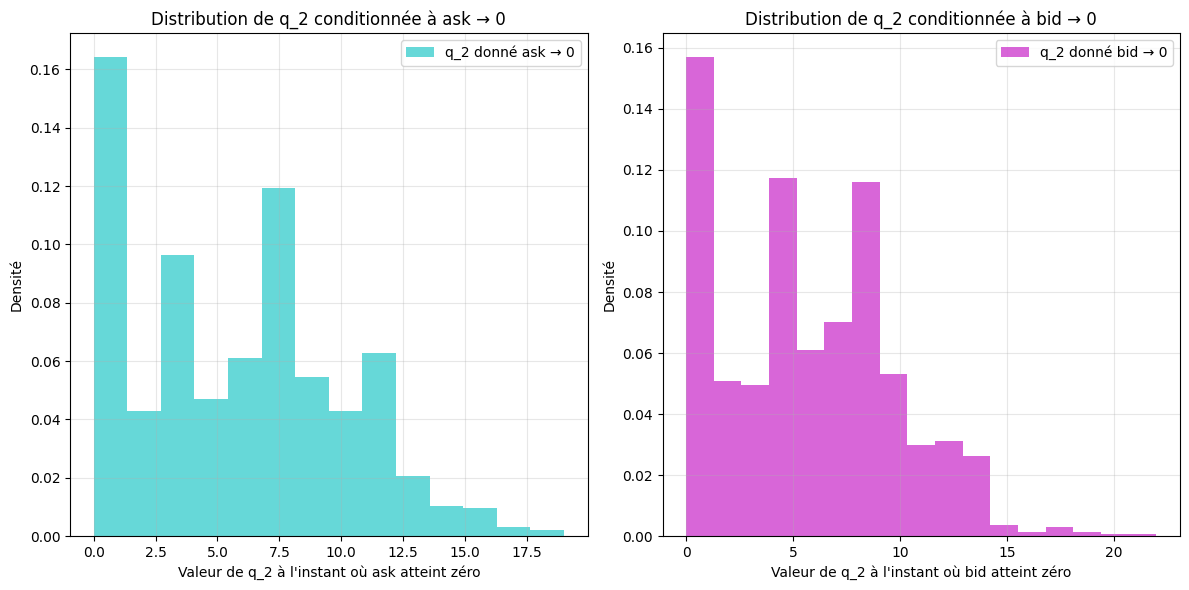

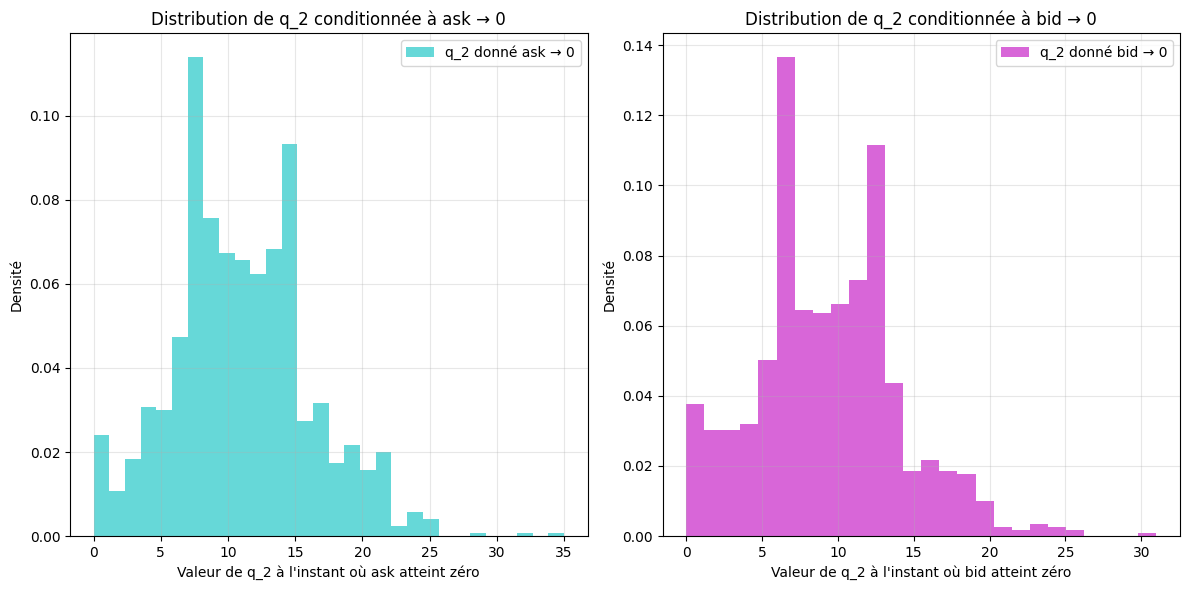

In [74]:
simulate_second_limit_distribution(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, lambda_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2, q_0_2=Q_0_2, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B, num_desired=1000)
simulate_second_limit_with_time_varying_lambda(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, a=0.5, b=1, mu_plus_ask_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2, q_0_2=Q_0_2, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B, num_desired=1000)

## 14. Passage au prix

Nous construisons maintenant la **trajectoire du mid-price** en modélisant simultanément
les **deux premières limites** (Hawkes couplé) et les **deux deuxièmes limites**
(Poisson à intensité variable) du carnet d'ordres.

### Architecture du modèle à quatre limites

On maintient à tout instant quatre files :
- $q_{a,1}$ : première limite ask (la plus proche du mid-price côté vendeur)
- $q_{a,2}$ : deuxième limite ask
- $q_{b,1}$ : première limite bid (la plus proche du mid-price côté acheteur)
- $q_{b,2}$ : deuxième limite bid

Toutes initialisées à $q_0$.

### Dynamique des premières limites : Hawkes couplé

Les files $q_{a,1}$ et $q_{b,1}$ évoluent selon le **processus de Hawkes couplé** de la
section 10 : les décréments de l'ask excitent la dynamique du bid (et vice versa).
La simulation s'arrête dès que l'une des deux atteint zéro.

**Continuité des intensités entre cycles** : lors du passage au cycle suivant, les
valeurs finales $\lambda_a^\tau$ et $\lambda_b^\tau$ servent d'intensités initiales pour
le nouveau cycle Hawkes, préservant ainsi la mémoire du processus.

### Dynamique des deuxièmes limites : Poisson à intensité variable

Pendant le même intervalle $[0,\tau]$, les files $q_{a,2}$ et $q_{b,2}$ évoluent comme
des **processus de Poisson à intensité variable** (section 13), dont l'intensité est
excitée par les décréments de la première limite correspondante via un noyau exponentiel.

### Mécanique du saut de prix

Lorsque la première limite ask $q_{a,1}$ s'épuise :
$$q_{a,1} \leftarrow q_{a,2}, \quad q_{a,2} \leftarrow q_0, \quad p_0 \uparrow \tfrac{\delta^p}{2}$$

Symétriquement, si c'est $q_{b,1}$ qui s'épuise :
$$q_{b,1} \leftarrow q_{b,2}, \quad q_{b,2} \leftarrow q_0, \quad p_0 \downarrow \tfrac{\delta^p}{2}$$

La côte survivante conserve son niveau courant et continue dans le cycle suivant.


In [75]:
try:
    from numba import njit as _njit
    _NUMBA = True
except ImportError:
    def _njit(f): return f
    _NUMBA = False


@_njit
def _hawkes_loop(mu_a, mu_b, alpha, beta, lp_a, lp_b, q_a, q_b, la0, lb0):
    """Ogata thinning for coupled Hawkes (first limits). Numba-accelerated."""
    MAX = 100000
    ta = np.empty(MAX); qa = np.empty(MAX, dtype=np.int64)
    tb = np.empty(MAX); qb = np.empty(MAX, dtype=np.int64)
    na = nb = 1
    ta[0] = 0.; qa[0] = q_a; tb[0] = 0.; qb[0] = q_b
    t = tla = tlb = 0.
    la = la0; lb = lb0
    while q_a > 0 and q_b > 0:
        ba = la if la > mu_a else mu_a
        bb = lb if lb > mu_b else mu_b
        sup = ba + bb + lp_a + lp_b
        tp = t + np.random.exponential(1. / sup)
        pa = mu_a + (la - mu_a) * np.exp(-beta * (tp - tla))
        pb = mu_b + (lb - mu_b) * np.exp(-beta * (tp - tlb))
        ea = pa if pa > 0. else 0.
        eb = pb if pb > 0. else 0.
        u = np.random.random()
        if u < lp_a / sup:
            q_a += 1; t = tp; tla = t; la = pa - alpha; lb = pb + alpha
            ta[na] = t; qa[na] = q_a; na += 1
        elif u < (ea + lp_a) / sup:
            q_a -= 1; t = tp; tla = t; la = pa + alpha; lb = pb - alpha
            ta[na] = t; qa[na] = q_a; na += 1
        elif u < (ba + lp_a) / sup:
            la = pa; lb = pb; tla = tp; t = tp
        elif u < (ba + lp_a + lp_b) / sup:
            q_b += 1; t = tp; tlb = t; lb = pb - alpha; la = pa + alpha
            tb[nb] = t; qb[nb] = q_b; nb += 1
        elif u < (ba + lp_a + eb + lp_b) / sup:
            q_b -= 1; t = tp; tlb = t; lb = pb + alpha; la = pa - alpha
            tb[nb] = t; qb[nb] = q_b; nb += 1
        else:
            lb = pb; la = pa; tlb = tp; t = tp
    tau = ta[na-1] if ta[na-1] > tb[nb-1] else tb[nb-1]
    return ta[:na], qa[:na], tb[:nb], qb[:nb], la, lb, tau


@_njit
def _second_limit(decr_times, a, b, mu_p, lm, q0, tau):
    """Time-varying Poisson for a second limit queue. Numba-accelerated."""
    MAX = 50000
    ot = np.empty(MAX); oq = np.empty(MAX, dtype=np.int64)
    n = 1; ot[0] = 0.; oq[0] = q0
    q = q0; t = 0.
    nd = len(decr_times)
    rate = mu_p + a * nd + lm
    while t < tau:
        t += np.random.exponential(1. / rate)
        if t >= tau:
            break
        lp = mu_p
        for i in range(nd):
            if decr_times[i] < t:
                lp += a * np.exp(-b * (t - decr_times[i]))
        u = np.random.random()
        if u < lp / rate:
            q += 1
            ot[n] = t; oq[n] = q; n += 1
        elif u < (lp + lm) / rate:
            q -= 1
            if q < 0: q = 0
            ot[n] = t; oq[n] = q; n += 1
    return ot[:n], oq[:n]


# Trigger JIT compilation once at import time (avoids slow first run)
_hawkes_loop(2., 2., .5, 1., 1.2, 1.2, 5, 5, 2., 2.)
_second_limit(np.array([0.5, 1.0]), 0.8, 1.0, 1.2, 2.0, 5, 5.0)
print(f'Numba JIT ({"actif" if _NUMBA else "non disponible — mode Python pur"})')


# ── Wrapper (backward-compatible signature for other callers) ─────────────────
def simulate_coupled_hawkes_with_intensities(
        mu_minus_a, mu_minus_b, alpha, beta,
        lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
        q_0_a=Q_0_A, q_0_b=Q_0_B,
        lambda_a_0=None, lambda_b_0=None):
    ta, qa, tb, qb, la_f, lb_f, tau = _hawkes_loop(
        float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
        float(lambda_plus_a), float(lambda_plus_b),
        int(q_0_a), int(q_0_b),
        float(lambda_a_0 if lambda_a_0 is not None else mu_minus_a),
        float(lambda_b_0 if lambda_b_0 is not None else mu_minus_b))
    merged = np.union1d(ta, tb)
    return (merged.tolist(), ta.tolist(), tb.tolist(),
            qa.tolist(), qb.tolist(), la_f, lb_f)


# ── Main price simulation ─────────────────────────────────────────────────────
def simulate_price_process_v2(n_cycles, mu_minus_a, mu_minus_b, alpha, beta,
                               a, b,
                               lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                               mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                               q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2, delta_p=1.0):
    mid_price = 0.0; t_cumul = 0.0
    price_times = [0.0]; price_values = [mid_price]
    q_a1, q_b1 = int(q_0_a), int(q_0_b)
    la0, lb0 = float(mu_minus_a), float(mu_minus_b)

    fa, fb, a_, b_ = float(a), float(b), float(mu_plus_2), float(lambda_minus_2)

    for _ in range(n_cycles):
        ta, qa, tb, qb, la_f, lb_f, tau = _hawkes_loop(
            float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
            float(lambda_plus_a), float(lambda_plus_b), q_a1, q_b1, la0, lb0)

        # Decrement times as contiguous float64 arrays for _second_limit
        ask_decr = ta[1:][qa[1:] < qa[:-1]]
        bid_decr = tb[1:][qb[1:] < qb[:-1]]

        _, q2a = _second_limit(ask_decr, fa, fb, a_, b_, int(q_0_2), tau)
        _, q2b = _second_limit(bid_decr, fa, fb, a_, b_, int(q_0_2), tau)

        t_cumul += tau
        q_a2 = max(1, int(q2a[-1]))
        q_b2 = max(1, int(q2b[-1]))

        if int(qa[-1]) == 0:           # ask exhausted -> price up
            mid_price += delta_p / 2
            q_a1 = q_a2
            q_b1 = max(1, int(qb[-1]))
        else:                           # bid exhausted -> price down
            mid_price -= delta_p / 2
            q_b1 = q_b2
            q_a1 = max(1, int(qa[-1]))

        la0 = la_f; lb0 = lb_f
        price_times.append(t_cumul)
        price_values.append(mid_price)

    return price_times, price_values


def plot_price_path(price_times, price_values, title='Trajectoire du mid-price'):
    plt.figure(figsize=(12, 4))
    plt.step(price_times, price_values, where='post', color='steelblue', linewidth=1.5)
    plt.xlabel('Temps')
    plt.ylabel('Mid-price $p_0$')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def analyze_price_increments_v2(n_simulations, mu_minus_a, mu_minus_b, alpha, beta,
                                 lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                                 q_0_a=Q_0_A, q_0_b=Q_0_B, delta_p=1.0):
    up_moves = 0
    for _ in range(n_simulations):
        _, _, _, q_a_values, _ = simulated_coupled_hawkes_processes(
            mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
        if q_a_values[-1] == 0:
            up_moves += 1
    p_up = up_moves / n_simulations
    p_down = 1 - p_up
    drift = delta_p / 2 * (p_up - p_down)
    print(f'P(hausse) = P(\u03c4_a < \u03c4_b) \u2248 {p_up:.3f}')
    print(f'P(baisse) = P(\u03c4_b < \u03c4_a) \u2248 {p_down:.3f}')
    print(f'D\u00e9rive par cycle : {drift:+.4f}')
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(['Hausse (+\u03b4/2)', 'Baisse (\u2212\u03b4/2)'], [p_up, p_down],
           color=['forestgreen', 'crimson'], alpha=0.75, edgecolor='black')
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='p = 0.5 (martingale)')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Probabilit\u00e9 estim\u00e9e')
    ax.set_title('Distribution des incr\u00e9ments de prix')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return p_up


def long_run_price_distribution_v2(n_paths, n_cycles, mu_minus_a, mu_minus_b, alpha, beta,
                                    a, b,
                                    lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                                    mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                                    q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2, delta_p=1.0):
    terminal_prices = np.array([
        simulate_price_process_v2(
            n_cycles, mu_minus_a, mu_minus_b, alpha, beta, a, b,
            lambda_plus_a, lambda_plus_b, mu_plus_2, lambda_minus_2,
            q_0_a, q_0_b, q_0_2, delta_p)[1][-1]
        for _ in range(n_paths)
    ])
    plt.figure(figsize=(8, 5))
    plt.hist(terminal_prices, bins='auto', density=True, alpha=0.65,
             color='steelblue', label=f'Prix final ({n_paths} trajectoires)')
    plt.xlabel('Prix final $p_0$')
    plt.ylabel('Densit\u00e9')
    plt.title(f'Distribution du prix apr\u00e8s {n_cycles} cycles ({n_paths} trajectoires)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return terminal_prices


Numba JIT (actif)


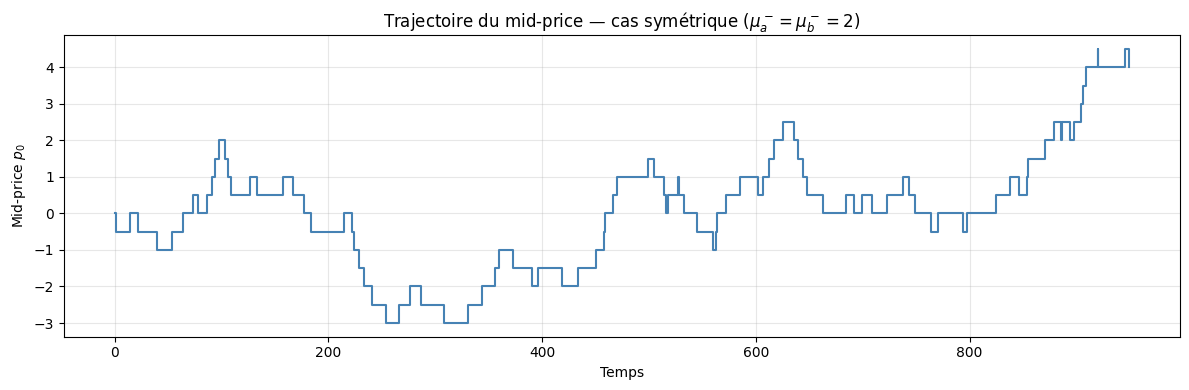

P(hausse) = P(τ_a < τ_b) ≈ 0.511
P(baisse) = P(τ_b < τ_a) ≈ 0.489
Dérive par cycle : +0.0115


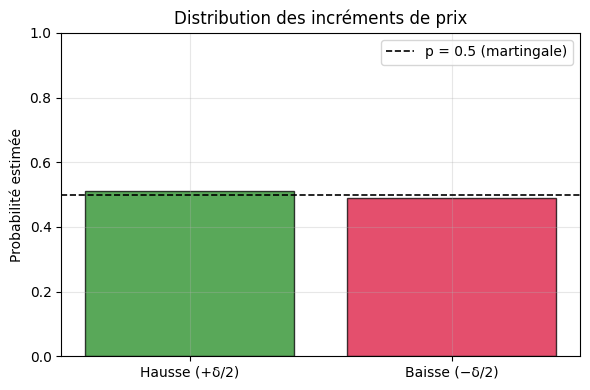

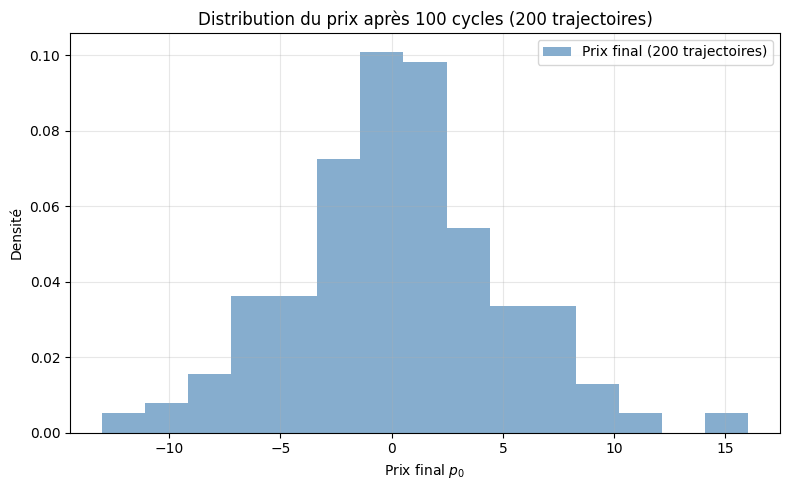

In [76]:
# Cas symétrique : mu_a^- = mu_b^-  →  martingale (p ≈ 0.5)
price_times_sym, price_values_sym = simulate_price_process_v2(
    n_cycles=100, mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, a=0.8, b=1.0)
plot_price_path(price_times_sym, price_values_sym,
                title='Trajectoire du mid-price — cas sym\u00e9trique ($\\mu_a^- = \\mu_b^- = 2$)')

p_up_sym = analyze_price_increments_v2(
    n_simulations=2000, mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1)

values = long_run_price_distribution_v2(
    n_paths=200, n_cycles=100,
    mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, a=0.8, b=1.0)


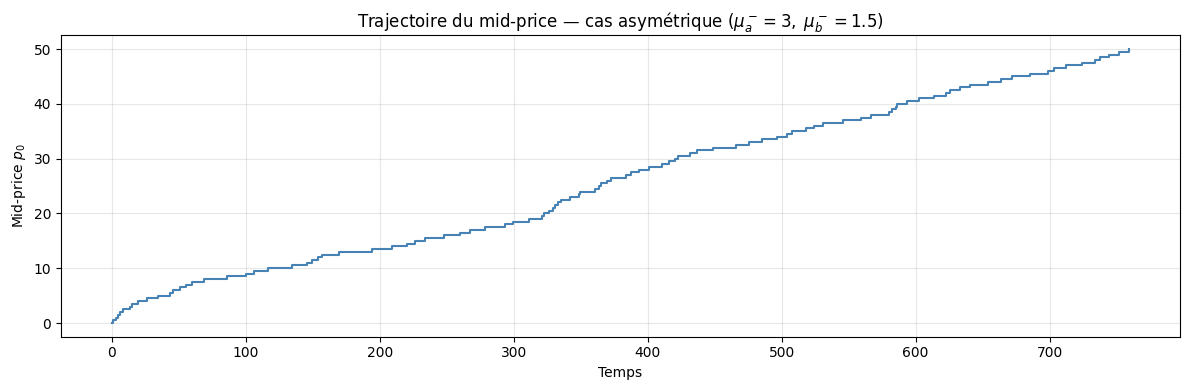

P(hausse) = P(τ_a < τ_b) ≈ 0.933
P(baisse) = P(τ_b < τ_a) ≈ 0.067
Dérive par cycle : +0.4335


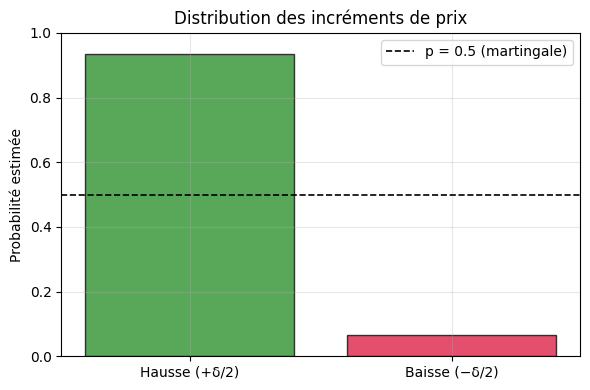

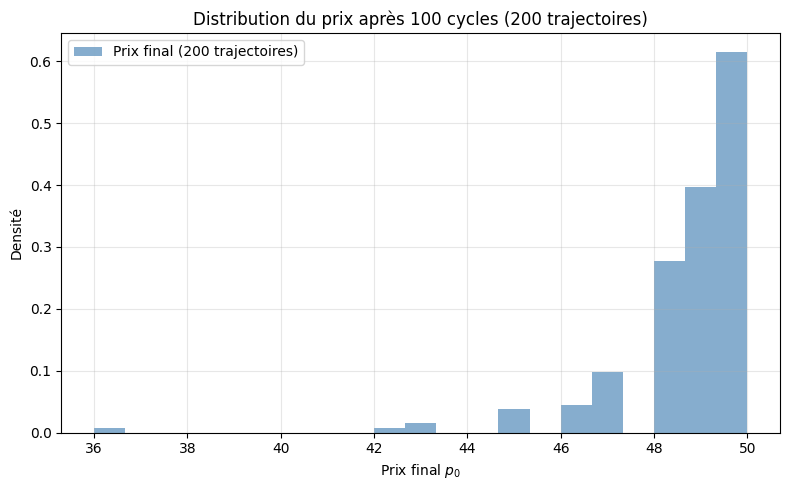

In [77]:
# Cas asymétrique : mu_a^- > mu_b^-  →  pression vendeuse accrue, dérive positive du prix
price_times_asym, price_values_asym = simulate_price_process_v2(
    n_cycles=100, mu_minus_a=3, mu_minus_b=1.5, alpha=0.5, beta=1, a=0.8, b=1.0)
plot_price_path(price_times_asym, price_values_asym,
                title='Trajectoire du mid-price — cas asym\u00e9trique ($\\mu_a^- = 3,\\; \\mu_b^- = 1.5$)')

p_up_asym = analyze_price_increments_v2(
    n_simulations=2000, mu_minus_a=3, mu_minus_b=1.5, alpha=0.5, beta=1)

values = long_run_price_distribution_v2(
    n_paths=200, n_cycles=100,
    mu_minus_a=3, mu_minus_b=1.5, alpha=0.5, beta=1, a=0.8, b=1.0)


In [78]:
import matplotlib.gridspec as gridspec

EPS_T = 1e-10  # tiny offset so queue-shift jumps appear cleanly in step plots


def simulate_order_book_evolution(n_cycles, mu_minus_a, mu_minus_b, alpha, beta,
                                   a, b,
                                   lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                                   mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                                   q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2, delta_p=1.0):
    """Run n_cycles and collect the full 4-queue state history for visualization."""
    mid_price = 0.0; t_cumul = 0.0
    q_a1, q_b1 = int(q_0_a), int(q_0_b)
    la0, lb0 = float(mu_minus_a), float(mu_minus_b)
    fa, fb, mp, lm = float(a), float(b), float(mu_plus_2), float(lambda_minus_2)

    price_times  = [0.0]; price_values  = [mid_price]
    q_a1_times   = [0.0]; q_a1_values   = [q_0_a]
    q_b1_times   = [0.0]; q_b1_values   = [q_0_b]
    q_a2_times   = [0.0]; q_a2_values   = [q_0_2]
    q_b2_times   = [0.0]; q_b2_values   = [q_0_2]
    price_change_times = []; price_change_dirs = []

    for _ in range(n_cycles):
        ta, qa, tb, qb, la_f, lb_f, tau = _hawkes_loop(
            float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
            float(lambda_plus_a), float(lambda_plus_b), q_a1, q_b1, la0, lb0)

        ask_decr = ta[1:][qa[1:] < qa[:-1]]
        bid_decr = tb[1:][qb[1:] < qb[:-1]]

        t2_a, q2_a = _second_limit(ask_decr, fa, fb, mp, lm, int(q_0_2), tau)
        t2_b, q2_b = _second_limit(bid_decr, fa, fb, mp, lm, int(q_0_2), tau)

        # First-limit trajectories (global time)
        for j in range(1, len(ta)):
            q_a1_times.append(t_cumul + ta[j]); q_a1_values.append(int(qa[j]))
        for j in range(1, len(tb)):
            q_b1_times.append(t_cumul + tb[j]); q_b1_values.append(int(qb[j]))

        # Second-limit trajectories (global time)
        for j in range(1, len(t2_a)):
            q_a2_times.append(t_cumul + t2_a[j]); q_a2_values.append(int(q2_a[j]))
        for j in range(1, len(t2_b)):
            q_b2_times.append(t_cumul + t2_b[j]); q_b2_values.append(int(q2_b[j]))

        t_cumul += tau
        q_a2_fin = max(1, int(q2_a[-1])); q_b2_fin = max(1, int(q2_b[-1]))

        if int(qa[-1]) == 0:
            mid_price += delta_p / 2; price_change_dirs.append(+1)
            q_a1 = q_a2_fin; q_b1 = max(1, int(qb[-1]))
        else:
            mid_price -= delta_p / 2; price_change_dirs.append(-1)
            q_b1 = q_b2_fin; q_a1 = max(1, int(qa[-1]))

        price_change_times.append(t_cumul)
        price_times.append(t_cumul); price_values.append(mid_price)

        # Queue-shift jump (EPS_T offset for clean step-plot rendering)
        q_a1_times.append(t_cumul + EPS_T); q_a1_values.append(q_a1)
        q_b1_times.append(t_cumul + EPS_T); q_b1_values.append(q_b1)
        q_a2_times.append(t_cumul + EPS_T); q_a2_values.append(int(q_0_2))
        q_b2_times.append(t_cumul + EPS_T); q_b2_values.append(int(q_0_2))

        la0 = la_f; lb0 = lb_f

    return dict(
        price_times=np.array(price_times),   price_values=np.array(price_values),
        q_a1_times=np.array(q_a1_times),     q_a1_values=np.array(q_a1_values),
        q_b1_times=np.array(q_b1_times),     q_b1_values=np.array(q_b1_values),
        q_a2_times=np.array(q_a2_times),     q_a2_values=np.array(q_a2_values),
        q_b2_times=np.array(q_b2_times),     q_b2_values=np.array(q_b2_values),
        price_change_times=np.array(price_change_times),
        price_change_dirs=np.array(price_change_dirs),
    )


def plot_order_book_evolution(data, title_suffix='', figsize=(15, 9)):
    C_ASK1  = '#c0392b'
    C_ASK2  = '#f0a899'
    C_BID1  = '#1a5276'
    C_BID2  = '#7fb3d3'
    C_PRICE = '#1e8449'
    C_UP    = '#27ae60'
    C_DOWN  = '#c0392b'

    fig, (ax_p, ax_a, ax_b) = plt.subplots(
        3, 1, figsize=figsize, facecolor='white',
        gridspec_kw={'height_ratios': [2, 1.5, 1.5]},
        sharex=True, constrained_layout=True)

    t_max = float(data['price_times'][-1])

    # ── Panel 1 : mid-price ─────────────────────────────────────────────
    ax_p.step(data['price_times'], data['price_values'], where='post',
              color=C_PRICE, linewidth=2.2, zorder=3)
    ax_p.fill_between(data['price_times'], data['price_values'],
                      data['price_values'].min() - 0.5,
                      step='post', color=C_PRICE, alpha=0.08, zorder=1)
    for i, (t, d) in enumerate(zip(data['price_change_times'], data['price_change_dirs'])):
        p_after = data['price_values'][i + 1]
        ax_p.scatter([t], [p_after],
                     color=C_UP if d > 0 else C_DOWN,
                     marker='^' if d > 0 else 'v',
                     s=80, zorder=5, linewidths=0)
    ax_p.set_ylabel('Mid-price $p_0$', fontsize=11)
    ax_p.set_title(
        f'\u00c9volution du carnet d\'ordres \u2014 {title_suffix}',
        fontsize=13, fontweight='bold', pad=9)

    # ── Panel 2 : ask ─────────────────────────────────────────────────
    ax_a.step(data['q_a1_times'], data['q_a1_values'], where='post',
              color=C_ASK1, linewidth=1.8, label='$q_{a,1}$ — Hawkes couplé', zorder=3)
    ax_a.step(data['q_a2_times'], data['q_a2_values'], where='post',
              color=C_ASK2, linewidth=1.3, linestyle='--', alpha=0.90,
              label='$q_{a,2}$ — Poisson variable', zorder=2)
    ax_a.fill_between(data['q_a1_times'], data['q_a1_values'], 0,
                      step='post', color=C_ASK1, alpha=0.13, zorder=1)
    ax_a.set_ylabel('File ask', fontsize=11)
    ax_a.legend(loc='upper right', fontsize=9.5, framealpha=0.92,
                ncol=2, edgecolor='#cccccc')

    # ── Panel 3 : bid ─────────────────────────────────────────────────
    ax_b.step(data['q_b1_times'], data['q_b1_values'], where='post',
              color=C_BID1, linewidth=1.8, label='$q_{b,1}$ — Hawkes couplé', zorder=3)
    ax_b.step(data['q_b2_times'], data['q_b2_values'], where='post',
              color=C_BID2, linewidth=1.3, linestyle='--', alpha=0.90,
              label='$q_{b,2}$ — Poisson variable', zorder=2)
    ax_b.fill_between(data['q_b1_times'], data['q_b1_values'], 0,
                      step='post', color=C_BID1, alpha=0.13, zorder=1)
    ax_b.set_ylabel('File bid', fontsize=11)
    ax_b.set_xlabel('Temps', fontsize=11)
    ax_b.legend(loc='upper right', fontsize=9.5, framealpha=0.92,
                ncol=2, edgecolor='#cccccc')

    # ── Shared decorations ──────────────────────────────────────────────
    for ax in (ax_p, ax_a, ax_b):
        for t, d in zip(data['price_change_times'], data['price_change_dirs']):
            ax.axvline(t, color=C_UP if d > 0 else C_DOWN,
                       alpha=0.18, linewidth=0.9, zorder=0)
        ax.set_xlim(0, t_max)
        ax.grid(True, alpha=0.30, linewidth=0.6, linestyle=':')
        ax.set_facecolor('#fafafa')
        for sp in ax.spines.values():
            sp.set_linewidth(0.7); sp.set_color('#cccccc')

    plt.setp(ax_p.get_xticklabels(), visible=False)
    plt.setp(ax_a.get_xticklabels(), visible=False)
    plt.show()


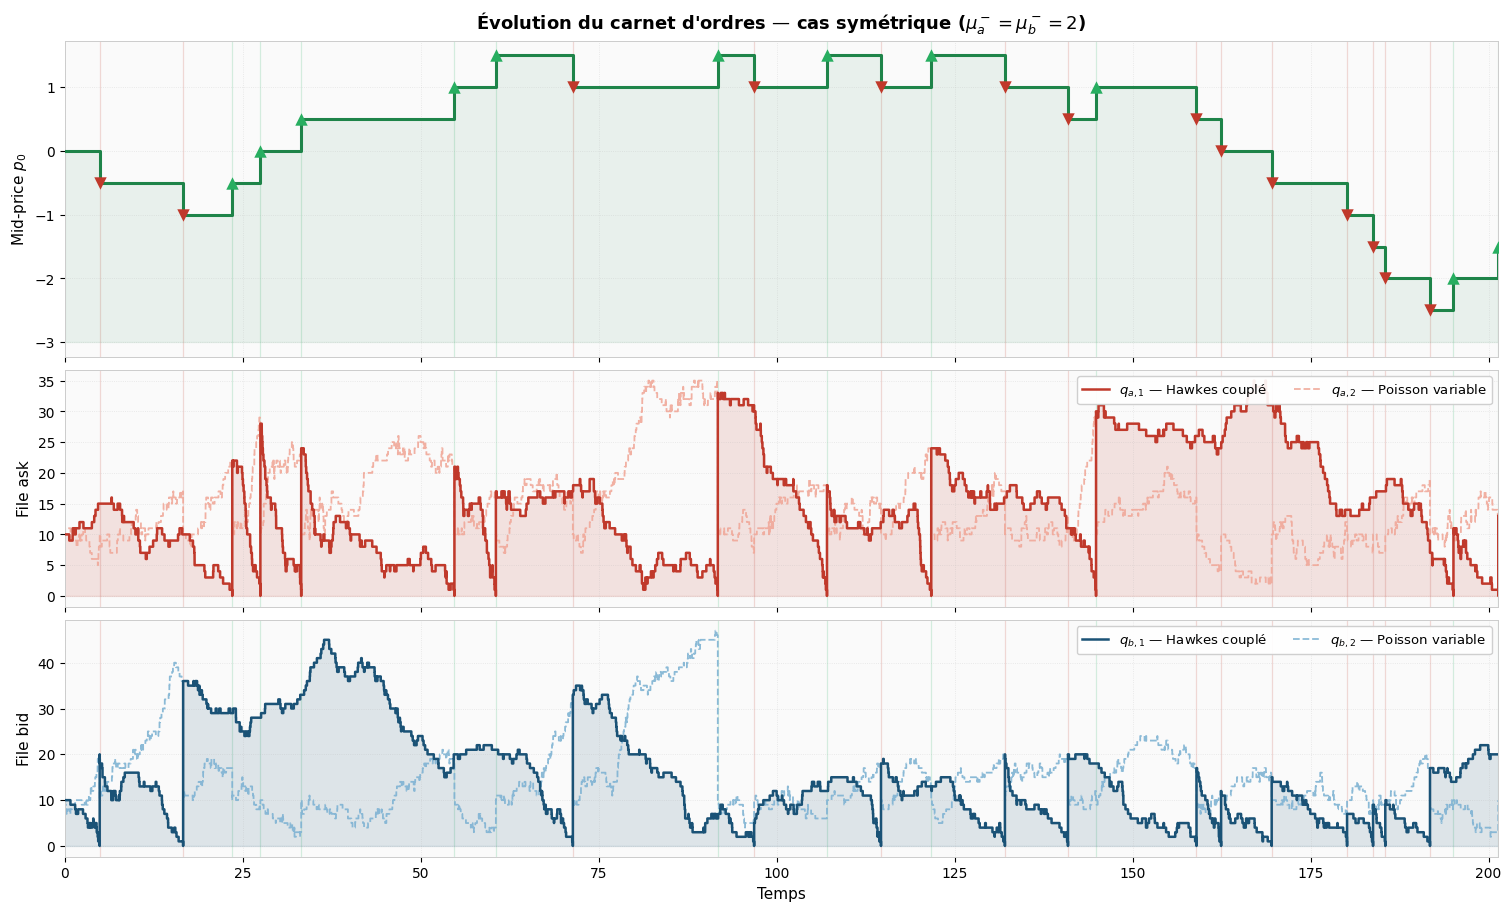

In [79]:
# Cas symétrique — visualisation de l'état du carnet d'ordres (25 cycles)
data_sym = simulate_order_book_evolution(
    n_cycles=25, mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, a=0.8, b=1.0)
plot_order_book_evolution(
    data_sym,
    title_suffix='cas sym\u00e9trique ($\\mu_a^- = \\mu_b^- = 2$)')


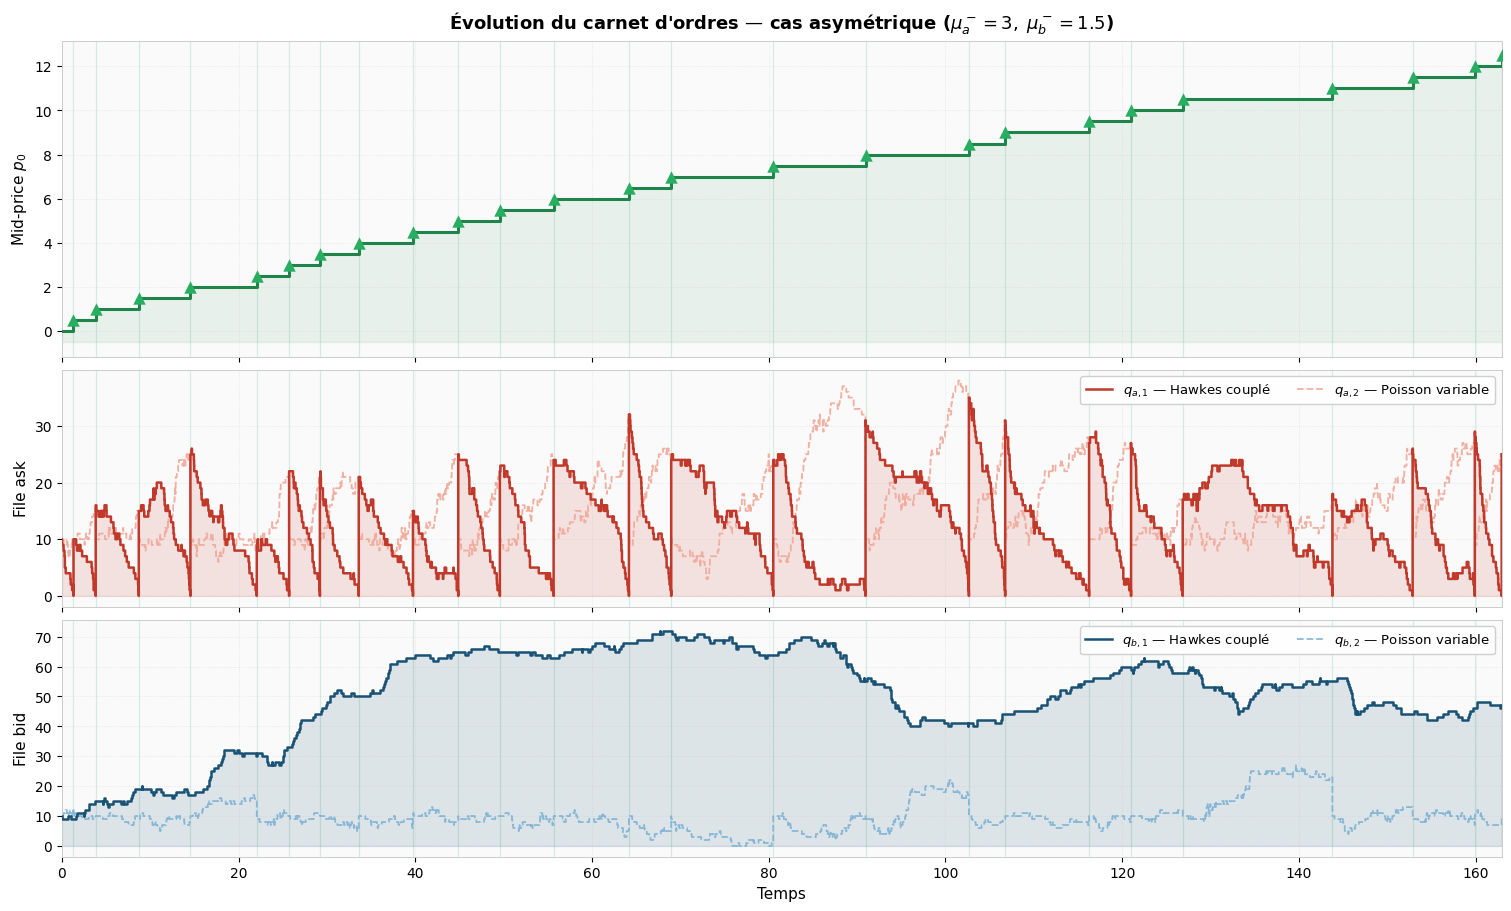

In [80]:
# Cas asymétrique — visualisation de l'état du carnet d'ordres (25 cycles)
data_asym = simulate_order_book_evolution(
    n_cycles=25, mu_minus_a=3, mu_minus_b=1.5, alpha=0.5, beta=1, a=0.8, b=1.0)
plot_order_book_evolution(
    data_asym,
    title_suffix='cas asym\u00e9trique ($\\mu_a^- = 3, \\; \\mu_b^- = 1.5$)')


## 15. Splitting pour la distribution conditionnelle de $Q_{a,2}$

### Problème et motivation

Dans la section 12, la distribution de $Q_{a,2}(\tau_a)$ conditionnellement à $\tau_a < \tau_b$
est estimée par **Monte Carlo direct** : on simule $N$ trajectoires Hawkes couplées et on
conserve celles où l'ask s'épuise en premier. Lorsque $p = \mathbb{P}(\tau_a < \tau_b) \ll 1$
(cas asymétrique $\mu_a^- \gg \mu_b^-$), seulement une fraction $p$ des trajectoires
contribuent : la variance de l'estimateur est $\propto (1-p)/(Np)$, ce qui diverge quand
$p \to 0$.

### Idée intuitive

Les trajectoires dont $q_{a,1}$ est déjà **proche de zéro** ont beaucoup plus de chances
d'atteindre l'épuisement $q_{a,1} = 0$. L'algorithme de **splitting multiniveau** exploite
cette observation : dès qu'une particule franchit un palier intermédiaire, on la
**clone** pour concentrer la simulation sur les trajectoires prometteuses.

### Algorithme formel (AMS à $N$ particules fixe)

**Niveaux** : on définit $Q_0$ paliers successifs
$$\mathcal{A}_k = \{q_{a,1} \leq k\}, \quad k = Q_0-1,\, Q_0-2,\, \ldots,\, 0.$$
Atteindre $\mathcal{A}_0 = \{q_{a,1} = 0\}$ est l'événement rare cible.

**Itération** : pour $k = Q_0-1$ jusqu'à $0$ :

1. Chaque particule en état $(q_{a,1}, q_{b,1}, \lambda_a, \lambda_b, t, \ldots)$ est simulée
   par le **processus de Hawkes couplé** jusqu'à ce que $q_{a,1}$ atteigne $k$
   (**succès**) ou $q_{b,1} = 0$ (**échec** — la particule est éliminée).  
   Les décréments de $q_{a,1}$ accumulés servent à exciter $Q_{a,2}$.

2. Soit $n_k$ le nombre de succès parmi $N$ particules.  
   On enregistre $\hat{p}_k = n_k/N$ et on **ré-échantillonne** $N$ copies parmi les
   $n_k$ survivants (avec remise), en héritant de l'état Hawkes complet
   $(\lambda_a^{\rm fin}, \lambda_b^{\rm fin}, t^{\rm fin}, \ldots)$.

3. À la fin ($q_{a,1} = 0$, instant $\tau_a$) : simuler $Q_{a,2}$ par le processus de
   Poisson à intensité variable (section 13) en utilisant l'historique complet des
   décréments accumulés.

**Continuité des intensités Hawkes** : les intensités finales $\lambda_a^{\rm fin},
\lambda_b^{\rm fin}$ d'une sous-simulation servent d'intensités initiales pour la
suivante, garantissant la cohérence de la trajectoire Hawkes sur $[0, \tau_a]$.

**Estimateur de la probabilité de conditionnement** :
$$\hat{p} = \prod_{k=0}^{Q_0-1} \hat{p}_k = \prod_{k=0}^{Q_0-1} \frac{n_k}{N}
\;\approx\; \mathbb{P}(\tau_a < \tau_b).$$

### Gain de variance

Pour MC direct avec $N_{\rm MC}$ trajectoires, le nombre effectif d'échantillons
conditionnels est $N_{\rm MC}\cdot p$. Avec le splitting et $N_{\rm split}$ particules,
toutes les particules atteignent $q_{a,1} = 0$, donnant $N_{\rm split}$ échantillons
conditionnels. Le gain est d'un facteur $\approx N_{\rm split} / (N_{\rm MC} \cdot p)$,
qui croît quand $p \to 0$.


In [81]:
@_njit
def _hawkes_one_level(mu_a, mu_b, alpha, beta, lp_a, lp_b,
                       q_a, q_b, la, lb, t, tla, tlb, target_a):
    """One coupled-Hawkes step for splitting: simulate until q_a <= target_a or q_b == 0."""
    MAX = 100000
    ta = np.empty(MAX); qa = np.empty(MAX, dtype=np.int64)
    tb = np.empty(MAX); qb = np.empty(MAX, dtype=np.int64)
    na = nb = 0
    while q_a > target_a and q_b > 0:
        ba = la if la > mu_a else mu_a
        bb = lb if lb > mu_b else mu_b
        sup = ba + bb + lp_a + lp_b
        tp = t + np.random.exponential(1. / sup)
        pa = mu_a + (la - mu_a) * np.exp(-beta * (tp - tla))
        pb = mu_b + (lb - mu_b) * np.exp(-beta * (tp - tlb))
        ea = pa if pa > 0. else 0.
        eb = pb if pb > 0. else 0.
        u = np.random.random()
        if u < lp_a / sup:
            q_a += 1; t = tp; tla = t; la = pa - alpha; lb = pb + alpha
            ta[na] = t; qa[na] = q_a; na += 1
        elif u < (ea + lp_a) / sup:
            q_a -= 1; t = tp; tla = t; la = pa + alpha; lb = pb - alpha
            ta[na] = t; qa[na] = q_a; na += 1
        elif u < (ba + lp_a) / sup:
            la = pa; lb = pb; tla = tp; t = tp
        elif u < (ba + lp_a + lp_b) / sup:
            q_b += 1; t = tp; tlb = t; lb = pb - alpha; la = pa + alpha
            tb[nb] = t; qb[nb] = q_b; nb += 1
        elif u < (ba + lp_a + eb + lp_b) / sup:
            q_b -= 1; t = tp; tlb = t; lb = pb + alpha; la = pa - alpha
            tb[nb] = t; qb[nb] = q_b; nb += 1
        else:
            lb = pb; la = pa; tlb = tp; t = tp
    return ta[:na], qa[:na], tb[:nb], qb[:nb], la, lb, t, tla, tlb, q_a <= target_a


# Warm-up JIT compilation
_hawkes_one_level(2., 2., .5, 1., 1.2, 1.2, 5, 5, 2., 2., 0., 0., 0., 4)
print('_hawkes_one_level compil\u00e9.')


def splitting_Q2_distribution(N_particles, mu_minus_a, mu_minus_b, alpha, beta,
                               a, b,
                               lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                               mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                               q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2):
    """
    Multilevel splitting estimator for P(Q_a2 | tau_a < tau_b).
    Fixed-N resampling: at each level survivors are bootstrapped back to N_particles.
    Returns (q_a2_values, estimated_p) where p = P(tau_a < tau_b).
    """
    mu_a = float(mu_minus_a); mu_b = float(mu_minus_b)
    al = float(alpha);        be = float(beta)
    lpa = float(lambda_plus_a); lpb = float(lambda_plus_b)
    a_ = float(a); b_ = float(b); mp = float(mu_plus_2); lm = float(lambda_minus_2)

    # Each particle carries the full Hawkes state + accumulated ask decrement history
    particles = [{'q_a': int(q_0_a), 'q_b': int(q_0_b),
                  'la': mu_a, 'lb': mu_b,
                  't': 0., 'tla': 0., 'tlb': 0.,
                  'decr_a': []}
                 for _ in range(N_particles)]
    prob = 1.0

    for target in range(int(q_0_a) - 1, -1, -1):
        survivors = []
        for p in particles:
            ta, qa, tb, qb, la_f, lb_f, t_f, tla_f, tlb_f, ok = _hawkes_one_level(
                mu_a, mu_b, al, be, lpa, lpb,
                p['q_a'], p['q_b'], p['la'], p['lb'],
                p['t'], p['tla'], p['tlb'], target)
            if ok:
                # Identify ask decrement times within this sub-simulation
                prev = np.empty(len(qa), dtype=np.int64)
                prev[0] = p['q_a']
                if len(qa) > 1:
                    prev[1:] = qa[:-1]
                new_decr = ta[qa < prev].tolist()
                survivors.append({
                    'q_a': int(qa[-1]),
                    'q_b': int(qb[-1]) if len(qb) else p['q_b'],
                    'la': la_f, 'lb': lb_f,
                    't': t_f, 'tla': tla_f, 'tlb': tlb_f,
                    'decr_a': p['decr_a'] + new_decr})

        n_s = len(survivors)
        if n_s == 0:
            return [], 0.0
        prob *= n_s / N_particles

        # Bootstrap back to N_particles (fixed-N AMS resampling)
        idx = np.random.choice(n_s, size=N_particles, replace=True)
        particles = [dict(survivors[i]) for i in idx]

    # Simulate Q_a2 for each surviving particle using the full decrement history
    q_a2_values = []
    for p in particles:
        td = (np.array(p['decr_a'], dtype=np.float64)
              if p['decr_a'] else np.empty(0, dtype=np.float64))
        _, q2v = _second_limit(td, a_, b_, mp, lm, int(q_0_2), float(p['t']))
        q_a2_values.append(int(q2v[-1]))

    return q_a2_values, prob


def plot_splitting_vs_mc(mu_minus_a, mu_minus_b, alpha, beta, a, b,
                          N_split=300, N_mc=3000,
                          lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                          mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                          q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2):
    # ── Splitting ──────────────────────────────────────────────────────────
    q2_spl, p_spl = splitting_Q2_distribution(
        N_split, mu_minus_a, mu_minus_b, alpha, beta, a, b,
        lambda_plus_a, lambda_plus_b, mu_plus_2, lambda_minus_2, q_0_a, q_0_b, q_0_2)

    # ── Direct MC ──────────────────────────────────────────────────────────
    q2_mc = []
    for _ in range(N_mc):
        ta, qa, tb, qb, _, _, tau = _hawkes_loop(
            float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
            float(lambda_plus_a), float(lambda_plus_b),
            int(q_0_a), int(q_0_b), float(mu_minus_a), float(mu_minus_b))
        if int(qa[-1]) == 0:
            decr = (ta[1:][qa[1:] < qa[:-1]]
                    if len(qa) > 1 else np.empty(0, dtype=np.float64))
            _, q2v = _second_limit(decr.astype(np.float64), float(a), float(b),
                                    float(mu_plus_2), float(lambda_minus_2),
                                    int(q_0_2), float(tau))
            q2_mc.append(int(q2v[-1]))
    p_mc = len(q2_mc) / N_mc

    print(f'Splitting : \u0070\u0302 = {p_spl:.3f} ({len(q2_spl)} \u00e9chantillons)'
          f'   MC direct : \u0070\u0302 = {p_mc:.3f} ({len(q2_mc)} succ\u00e8s / {N_mc})')

    all_vals = q2_spl + q2_mc
    if not all_vals:
        print('Aucune donn\u00e9e \u00e0 afficher.')
        return
    bins = np.arange(-0.5, max(all_vals) + 2.5, 1.0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white',
                              constrained_layout=True)

    axes[0].hist(q2_mc, bins=bins, density=True, alpha=0.78, color='#2980b9',
                  edgecolor='white', linewidth=0.5,
                  label=f'$N_{{\\rm MC}}={N_mc}$, {len(q2_mc)} succ\u00e8s'
                         f' ($\\hat{{p}}={p_mc:.3f}$)')
    axes[0].set_title('Monte Carlo direct', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('$Q_{a,2}(\\tau_a)$', fontsize=11)
    axes[0].set_ylabel('Densit\u00e9', fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3, linestyle=':')
    axes[0].set_facecolor('#fafafa')

    axes[1].hist(q2_spl, bins=bins, density=True, alpha=0.78, color='#e67e22',
                  edgecolor='white', linewidth=0.5,
                  label=f'$N_{{\\rm split}}={N_split}$ particules'
                         f' ($\\hat{{p}}={p_spl:.3f}$)')
    axes[1].set_title('Splitting multiniveau', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('$Q_{a,2}(\\tau_a)$', fontsize=11)
    axes[1].set_ylabel('Densit\u00e9', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3, linestyle=':')
    axes[1].set_facecolor('#fafafa')

    fig.suptitle(
        f'Distribution de $Q_{{a,2}}$ sachant $\\tau_a < \\tau_b$'
        f' \u2014 $\\mu_a^-={mu_minus_a},\\; \\mu_b^-={mu_minus_b}$',
        fontsize=12, fontweight='bold')
    plt.show()


# ─── Cas bid : cible q_b = 0 ─────────────────────────────────────────────────────────────────
@_njit
def _hawkes_one_level_bid(mu_a, mu_b, alpha, beta, lp_a, lp_b,
                           q_a, q_b, la, lb, t, tla, tlb, target_b):
    MAX = 100000
    ta = np.empty(MAX); qa = np.empty(MAX, dtype=np.int64)
    tb = np.empty(MAX); qb = np.empty(MAX, dtype=np.int64)
    na = nb_ = 0
    while q_b > target_b and q_a > 0:
        ba = la if la > mu_a else mu_a
        bb = lb if lb > mu_b else mu_b
        sup = ba + bb + lp_a + lp_b
        tp = t + np.random.exponential(1. / sup)
        pa = mu_a + (la - mu_a) * np.exp(-beta * (tp - tla))
        pb = mu_b + (lb - mu_b) * np.exp(-beta * (tp - tlb))
        ea = pa if pa > 0. else 0.
        eb = pb if pb > 0. else 0.
        u = np.random.random()
        if u < lp_a / sup:
            q_a += 1; t = tp; tla = t; la = pa - alpha; lb = pb + alpha
            ta[na] = t; qa[na] = q_a; na += 1
        elif u < (ea + lp_a) / sup:
            q_a -= 1; t = tp; tla = t; la = pa + alpha; lb = pb - alpha
            ta[na] = t; qa[na] = q_a; na += 1
        elif u < (ba + lp_a) / sup:
            la = pa; lb = pb; tla = tp; t = tp
        elif u < (ba + lp_a + lp_b) / sup:
            q_b += 1; t = tp; tlb = t; lb = pb - alpha; la = pa + alpha
            tb[nb_] = t; qb[nb_] = q_b; nb_ += 1
        elif u < (ba + lp_a + eb + lp_b) / sup:
            q_b -= 1; t = tp; tlb = t; lb = pb + alpha; la = pa - alpha
            tb[nb_] = t; qb[nb_] = q_b; nb_ += 1
        else:
            lb = pb; la = pa; tlb = tp; t = tp
    return ta[:na], qa[:na], tb[:nb_], qb[:nb_], la, lb, t, tla, tlb, q_b <= target_b


# Warm-up JIT
_hawkes_one_level_bid(2., 2., .5, 1., 1.2, 1.2, 5, 5, 2., 2., 0., 0., 0., 4)
print('_hawkes_one_level_bid compilé.')


def splitting_Q2_bid_distribution(N_particles, mu_minus_a, mu_minus_b, alpha, beta,
                                   a, b,
                                   lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                                   mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                                   q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2):
    mu_a = float(mu_minus_a); mu_b = float(mu_minus_b)
    al = float(alpha);        be = float(beta)
    lpa = float(lambda_plus_a); lpb = float(lambda_plus_b)
    a_ = float(a); b_ = float(b); mp = float(mu_plus_2); lm = float(lambda_minus_2)

    particles = [{'q_a': int(q_0_a), 'q_b': int(q_0_b),
                  'la': mu_a, 'lb': mu_b,
                  't': 0., 'tla': 0., 'tlb': 0.,
                  'decr_b': []}
                 for _ in range(N_particles)]
    prob = 1.0

    for target in range(int(q_0_b) - 1, -1, -1):
        survivors = []
        for p in particles:
            ta, qa, tb, qb, la_f, lb_f, t_f, tla_f, tlb_f, ok = _hawkes_one_level_bid(
                mu_a, mu_b, al, be, lpa, lpb,
                p['q_a'], p['q_b'], p['la'], p['lb'],
                p['t'], p['tla'], p['tlb'], target)
            if ok:
                prev = np.empty(len(qb), dtype=np.int64)
                prev[0] = p['q_b']
                if len(qb) > 1:
                    prev[1:] = qb[:-1]
                new_decr = tb[qb < prev].tolist()
                survivors.append({
                    'q_a': int(qa[-1]) if len(qa) else p['q_a'],
                    'q_b': int(qb[-1]),
                    'la': la_f, 'lb': lb_f,
                    't': t_f, 'tla': tla_f, 'tlb': tlb_f,
                    'decr_b': p['decr_b'] + new_decr})

        n_s = len(survivors)
        if n_s == 0:
            return [], 0.0
        prob *= n_s / N_particles

        idx = np.random.choice(n_s, size=N_particles, replace=True)
        particles = [dict(survivors[i]) for i in idx]

    q_b2_values = []
    for p in particles:
        td = (np.array(p['decr_b'], dtype=np.float64)
              if p['decr_b'] else np.empty(0, dtype=np.float64))
        _, q2v = _second_limit(td, a_, b_, mp, lm, int(q_0_2), float(p['t']))
        q_b2_values.append(int(q2v[-1]))

    return q_b2_values, prob


def plot_splitting_vs_mc_bid(mu_minus_a, mu_minus_b, alpha, beta, a, b,
                              N_split=300, N_mc=3000,
                              lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                              mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                              q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2):
    # ── Splitting ──────────────────────────────────────────────────────────
    q2_spl, p_spl = splitting_Q2_bid_distribution(
        N_split, mu_minus_a, mu_minus_b, alpha, beta, a, b,
        lambda_plus_a, lambda_plus_b, mu_plus_2, lambda_minus_2, q_0_a, q_0_b, q_0_2)

    # ── Direct MC ──────────────────────────────────────────────────────────
    q2_mc = []
    for _ in range(N_mc):
        ta, qa, tb, qb, _, _, tau = _hawkes_loop(
            float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
            float(lambda_plus_a), float(lambda_plus_b),
            int(q_0_a), int(q_0_b), float(mu_minus_a), float(mu_minus_b))
        if int(qb[-1]) == 0:
            decr = (tb[1:][qb[1:] < qb[:-1]]
                    if len(qb) > 1 else np.empty(0, dtype=np.float64))
            _, q2v = _second_limit(decr.astype(np.float64), float(a), float(b),
                                    float(mu_plus_2), float(lambda_minus_2),
                                    int(q_0_2), float(tau))
            q2_mc.append(int(q2v[-1]))
    p_mc = len(q2_mc) / N_mc

    print(f'Splitting : p\u0302 = {p_spl:.3f} ({len(q2_spl)} \u00e9chantillons)'
          f'   MC direct : p\u0302 = {p_mc:.3f} ({len(q2_mc)} succ\u00e8s / {N_mc})')

    all_vals = q2_spl + q2_mc
    if not all_vals:
        print('Aucune donn\u00e9e \u00e0 afficher.')
        return
    bins = np.arange(-0.5, max(all_vals) + 2.5, 1.0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white',
                              constrained_layout=True)

    axes[0].hist(q2_mc, bins=bins, density=True, alpha=0.78, color='#1a5276',
                  edgecolor='white', linewidth=0.5,
                  label=f'$N_{{\\rm MC}}={N_mc}$, {len(q2_mc)} succ\u00e8s'
                         f' ($\\hat{{p}}={p_mc:.3f}$)')
    axes[0].set_title('Monte Carlo direct', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('$Q_{b,2}(\\tau_b)$', fontsize=11)
    axes[0].set_ylabel('Densit\u00e9', fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3, linestyle=':')
    axes[0].set_facecolor('#fafafa')

    axes[1].hist(q2_spl, bins=bins, density=True, alpha=0.78, color='#117a65',
                  edgecolor='white', linewidth=0.5,
                  label=f'$N_{{\\rm split}}={N_split}$ particules'
                         f' ($\\hat{{p}}={p_spl:.3f}$)')
    axes[1].set_title('Splitting multiniveau', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('$Q_{b,2}(\\tau_b)$', fontsize=11)
    axes[1].set_ylabel('Densit\u00e9', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3, linestyle=':')
    axes[1].set_facecolor('#fafafa')

    fig.suptitle(
        f'Distribution de $Q_{{b,2}}$ sachant $\\tau_b < \\tau_a$'
        f' \u2014 $\\mu_a^-={mu_minus_a},\\; \\mu_b^-={mu_minus_b}$',
        fontsize=12, fontweight='bold')
    plt.show()


_hawkes_one_level compilé.
_hawkes_one_level_bid compilé.


Splitting : p̂ = 0.458 (300 échantillons)   MC direct : p̂ = 0.497 (1491 succès / 3000)


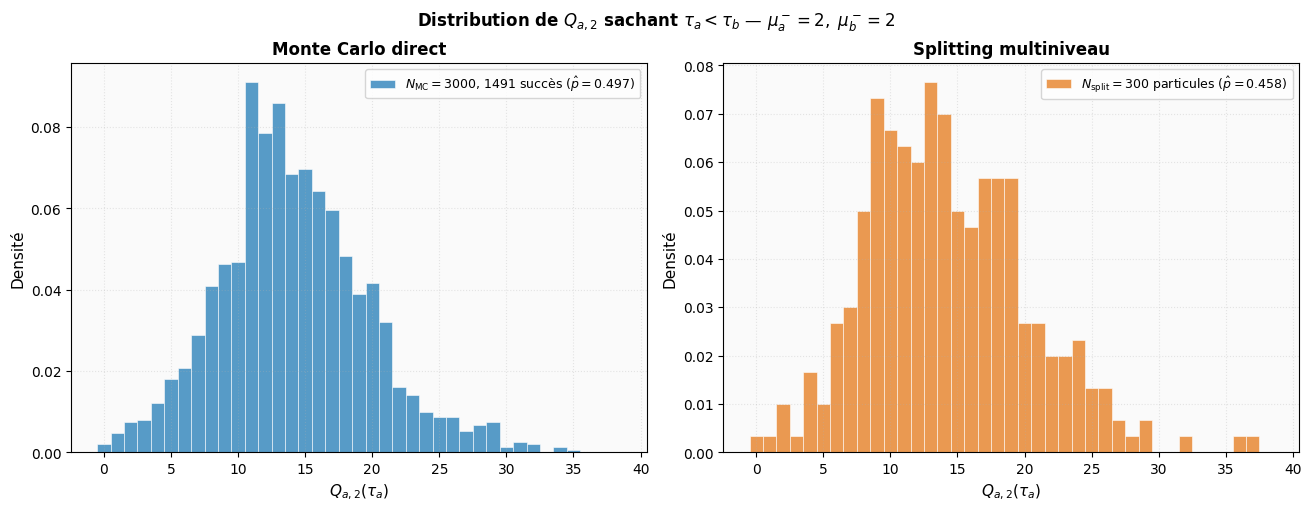

Splitting : p̂ = 0.929 (300 échantillons)   MC direct : p̂ = 0.924 (2772 succès / 3000)


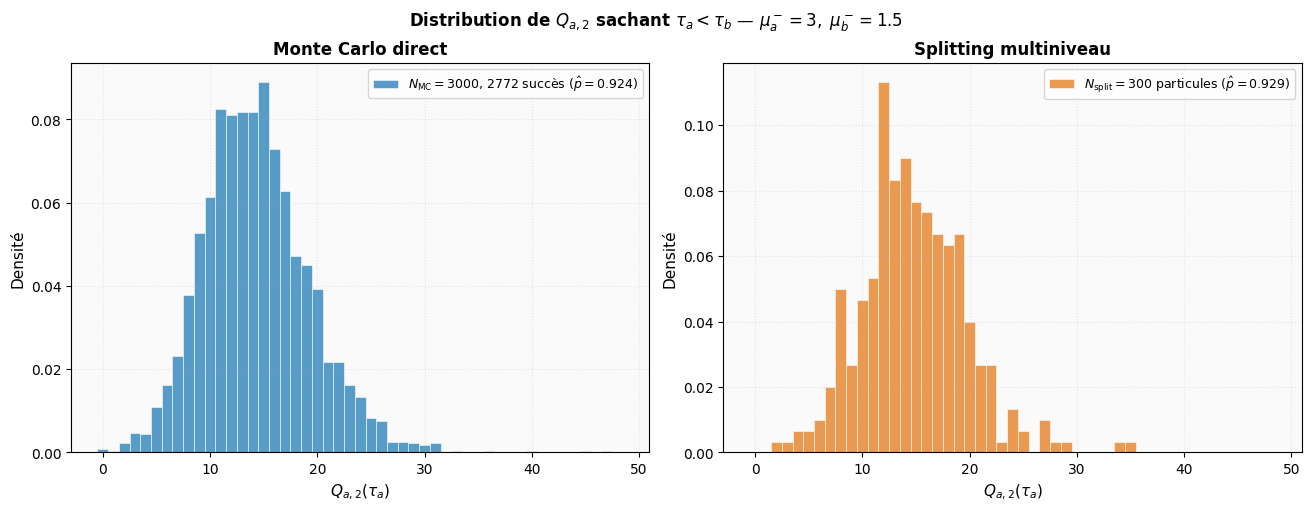


=== Cas bid : Q_{b,2} sachant tau_b < tau_a ===
Splitting : p̂ = 0.571 (300 échantillons)   MC direct : p̂ = 0.507 (1522 succès / 3000)


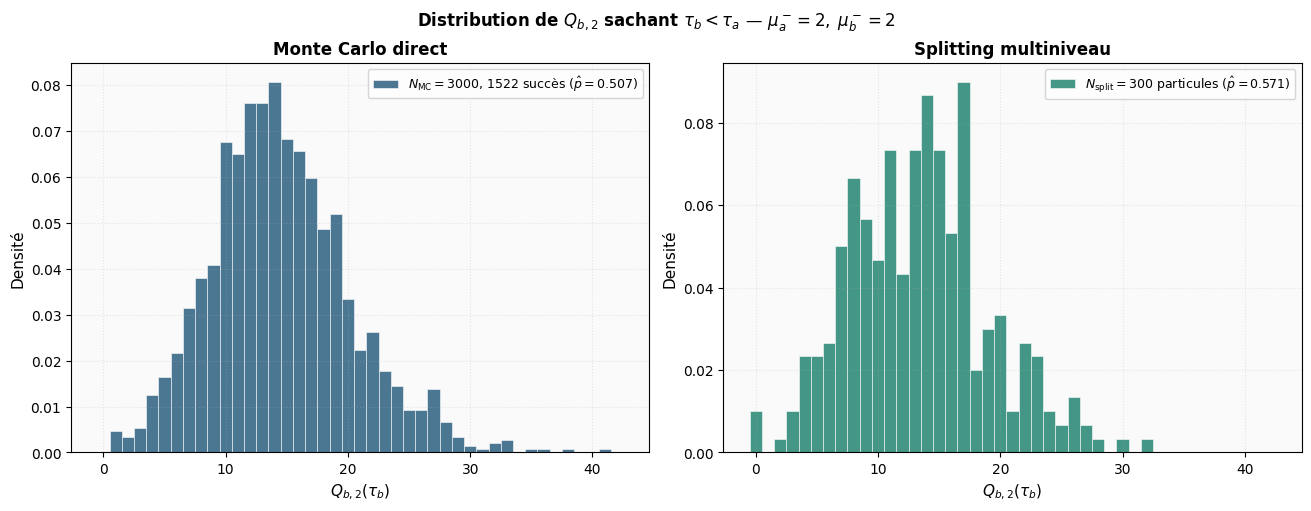

Splitting : p̂ = 0.081 (300 échantillons)   MC direct : p̂ = 0.061 (184 succès / 3000)


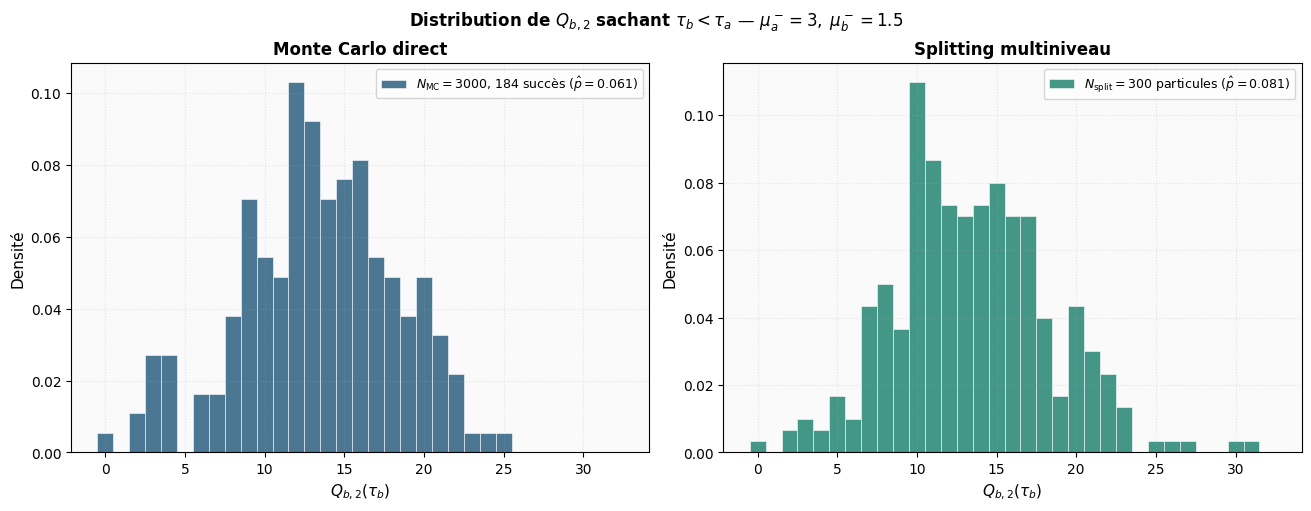

In [82]:
# Cas symétrique : p ≈ 0.5 — splitting et MC direct donnent des résultats similaires
plot_splitting_vs_mc(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, a=0.8, b=1.0,
                      N_split=300, N_mc=3000)

# Cas asymétrique : p < 0.5 — le splitting est plus efficace (moins de rejets)
plot_splitting_vs_mc(mu_minus_a=3, mu_minus_b=1.5, alpha=0.5, beta=1, a=0.8, b=1.0,
                      N_split=300, N_mc=3000)


print('\n=== Cas bid : Q_{b,2} sachant tau_b < tau_a ===')
# Cas symétrique
plot_splitting_vs_mc_bid(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, a=0.8, b=1.0,
                          N_split=300, N_mc=3000)

# Cas asymétrique : p > 0.5 pour le bid (mu_b < mu_a)
plot_splitting_vs_mc_bid(mu_minus_a=3, mu_minus_b=1.5, alpha=0.5, beta=1, a=0.8, b=1.0,
                          N_split=300, N_mc=3000)


## 16. Distribution des états aux niveaux de splitting

### Motivation

Dans l'algorithme de splitting (section 15), à chaque niveau $k$, seules les particules ayant survécu jusqu'à $\{q_{a,1} \leq k\}$ sont conservées. Ces survivants portent un **état complet** du processus de Hawkes :

$$s_k = \bigl(\lambda_a(t_k),\; \lambda_b(t_k),\; t_k,\; t_k^{(\lambda_a)},\; t_k^{(\lambda_b)},\; q_{b,1}(t_k),\; \mathcal{D}_a^k\bigr)$$

où $\mathcal{D}_a^k$ est l'ensemble des temps de décrémentation du premier ask jusqu'au niveau $k$.

**Observation clé :** les intensités $(\lambda_a, \lambda_b)$ au niveau $k$ ne sont **pas** égales aux valeurs basales $(\mu_a^-, \mu_b^-)$ — elles reflètent l'histoire des excitations mutuelles accumulées pour atteindre ce niveau. La distribution empirique de ces tuples, notée $\hat{\pi}_k$, capture la loi conditionnelle des états sachant $\{q_{a,1} \leq k\}$.

### Algorithme en deux phases

**Phase hors-ligne (une seule fois) :** on exécute le splitting complet avec $N$ particules et on enregistre l'ensemble des survivants $\hat{\pi}_k$ *avant* le rééchantillonnage à chaque niveau $k$. On stocke aussi le taux de survie conditionnel $\hat{p}_k = n_k / N$.

**Phase en ligne (répétable rapidement) :** pour générer un nouvel échantillon de $Q_{a,2}$ depuis le niveau $k^*$ :

1. **Bootstrapper** un état $s \sim \hat{\pi}_{k^*}$ (tirage uniforme parmi les survivants hors-ligne).
2. **Simuler** depuis $s$ jusqu'à $\{q_{a,1} = 0\}$ ou $\{q_{b,1} = 0\}$ via `_hawkes_one_level`.
3. Si l'ask atteint 0, simuler $Q_{a,2}$ avec `_second_limit`.

L'estimateur de probabilité se factorise :

$$\hat{P}(\tau_a < \tau_b) \;=\; \underbrace{\prod_{j=Q_0-1}^{k^*+1} \hat{p}_j}_{\displaystyle P_{\rm off}} \;\times\; \underbrace{\hat{P}\!\left(\tau_a < \tau_b \;\big|\; q_{a,1} \leq k^*\right)}_{\displaystyle P_{\rm on}}
$$

### Intérêt

En mémorisant $\hat{\pi}_k$, on **amortit** le coût des niveaux supérieurs (les plus coûteux en simulation) sur de nombreuses requêtes en ligne. La phase en ligne ne simule que les derniers $k^*$ niveaux depuis un état déjà conditionné — gain substantiel quand $Q_0 \gg k^*$.

On visualise la distribution de $(\lambda_a, \lambda_b)$ à différents niveaux pour confirmer que ces intensités contiennent une information non triviale sur le conditionnement.

In [83]:
import time as _time

# ─── Phase hors-ligne : collecte des distributions π_k ─────────────────────────────────────
def collect_level_states(N_particles, mu_minus_a, mu_minus_b, alpha, beta, a, b,
                         lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                         mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                         q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2):
    mu_a = float(mu_minus_a); mu_b = float(mu_minus_b)
    al = float(alpha);        be = float(beta)
    lpa = float(lambda_plus_a); lpb = float(lambda_plus_b)

    particles = [{'q_a': int(q_0_a), 'q_b': int(q_0_b),
                  'la': mu_a, 'lb': mu_b,
                  't': 0., 'tla': 0., 'tlb': 0.,
                  'decr_a': []}
                 for _ in range(N_particles)]

    level_states = {}
    level_probs  = {}

    for target in range(int(q_0_a) - 1, -1, -1):
        survivors = []
        for p in particles:
            ta, qa, tb, qb, la_f, lb_f, t_f, tla_f, tlb_f, ok = _hawkes_one_level(
                mu_a, mu_b, al, be, lpa, lpb,
                p['q_a'], p['q_b'], p['la'], p['lb'],
                p['t'], p['tla'], p['tlb'], target)
            if ok:
                prev = np.empty(len(qa), dtype=np.int64)
                prev[0] = p['q_a']
                if len(qa) > 1:
                    prev[1:] = qa[:-1]
                new_decr = ta[qa < prev].tolist()
                survivors.append({
                    'q_a': int(qa[-1]),
                    'q_b': int(qb[-1]) if len(qb) else p['q_b'],
                    'la': la_f, 'lb': lb_f,
                    't': t_f, 'tla': tla_f, 'tlb': tlb_f,
                    'decr_a': p['decr_a'] + new_decr})

        n_s = len(survivors)
        level_states[target] = survivors        # AVANT rééchantillonnage
        level_probs[target]  = n_s / N_particles

        if n_s == 0:
            break

        idx = np.random.choice(n_s, size=N_particles, replace=True)
        particles = [dict(survivors[i]) for i in idx]

    return level_states, level_probs


# ─── Phase en ligne : bootstrap depuis π_{start_k} ────────────────────────────────────
def sample_and_complete(level_states, level_probs, start_k, n_samples,
                        mu_minus_a, mu_minus_b, alpha, beta, a, b,
                        lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                        mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                        q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2):
    mu_a = float(mu_minus_a); mu_b = float(mu_minus_b)
    al = float(alpha);        be = float(beta)
    lpa = float(lambda_plus_a); lpb = float(lambda_plus_b)
    a_ = float(a); b_ = float(b)
    mp = float(mu_plus_2); lm = float(lambda_minus_2)

    # Probabilité hors-ligne : produit des taux Q_0-1 … start_k+1
    p_offline = 1.0
    for k in range(int(q_0_a) - 1, start_k, -1):
        p_offline *= level_probs.get(k, 0.0)

    pool = level_states.get(start_k, [])
    if not pool:
        return [], p_offline, 0.0

    q_a2_values = []
    n_reached = 0

    for _ in range(n_samples):
        p = dict(pool[np.random.randint(len(pool))])

        # Simulation directe depuis start_k jusqu'à q_a = 0
        ta, qa, tb, qb, la_f, lb_f, t_f, tla_f, tlb_f, ok = _hawkes_one_level(
            mu_a, mu_b, al, be, lpa, lpb,
            p['q_a'], p['q_b'], p['la'], p['lb'],
            p['t'], p['tla'], p['tlb'], 0)

        if ok:
            n_reached += 1
            prev = np.empty(len(qa), dtype=np.int64)
            prev[0] = p['q_a']
            if len(qa) > 1:
                prev[1:] = qa[:-1]
            new_decr  = ta[qa < prev].tolist()
            decr_all  = p['decr_a'] + new_decr
            td = (np.array(decr_all, dtype=np.float64)
                  if decr_all else np.empty(0, dtype=np.float64))
            _, q2v = _second_limit(td, a_, b_, mp, lm, int(q_0_2), float(t_f))
            q_a2_values.append(int(q2v[-1]))

    p_online = n_reached / n_samples if n_samples > 0 else 0.0
    return q_a2_values, p_offline, p_online


# ─── Visualisation (λ_a, λ_b) aux niveaux sélectionnés ───────────────────────────────────
def plot_lambda_at_levels(level_states, levels_to_show, mu_minus_a, mu_minus_b):
    n = len(levels_to_show)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5),
                              facecolor='white', constrained_layout=True)
    if n == 1:
        axes = [axes]

    palette = plt.cm.viridis(np.linspace(0.15, 0.85, n))

    for ax, k, col in zip(axes, levels_to_show, palette):
        states = level_states.get(k, [])
        if not states:
            ax.set_title(f'Niveau k={k} — aucun survivant')
            continue
        las = np.array([s['la'] for s in states])
        lbs = np.array([s['lb'] for s in states])
        ax.scatter(las, lbs, alpha=0.45, s=20, color=col, edgecolors='none')
        ax.axvline(mu_minus_a, color='#c0392b', lw=1.3, ls='--',
                   label=f'$\\mu_a^-={mu_minus_a}$')
        ax.axhline(mu_minus_b, color='#2980b9', lw=1.3, ls='--',
                   label=f'$\\mu_b^-={mu_minus_b}$')
        ax.set_xlabel('$\\lambda_a$', fontsize=11)
        ax.set_ylabel('$\\lambda_b$', fontsize=11)
        ax.set_title(f'Niveau $k={k}$  ({len(states)} surv.)',
                     fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3, linestyle=':')
        ax.set_facecolor('#fafafa')

    fig.suptitle(
        r'Distribution de $(\lambda_a,\,\lambda_b)$ aux niveaux de splitting'
        f' — $\\mu_a^-={mu_minus_a},\\;\\mu_b^-={mu_minus_b}$',
        fontsize=12, fontweight='bold')
    plt.show()


# ─── Comparaison Q_a2 : splitting complet vs bootstrap ────────────────────────────────
def plot_q2_level_comparison(q2_full, q2_from_k, start_k,
                              p_full, p_offline, p_online,
                              N_full, N_online):
    all_vals = q2_full + q2_from_k
    if not all_vals:
        print('Aucune donnée à afficher.')
        return
    bins = np.arange(-0.5, max(all_vals) + 2.5, 1.0)
    p_combined = p_offline * p_online

    fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                              facecolor='white', constrained_layout=True)

    axes[0].hist(q2_full, bins=bins, density=True, alpha=0.78, color='#e67e22',
                  edgecolor='white', linewidth=0.5,
                  label=f'$N={N_full}$,  $\\hat{{p}}={p_full:.3f}$')
    axes[0].set_title('Splitting complet (§15)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('$Q_{a,2}(\\tau_a)$', fontsize=11)
    axes[0].set_ylabel('Densité', fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3, linestyle=':')
    axes[0].set_facecolor('#fafafa')

    axes[1].hist(q2_from_k, bins=bins, density=True, alpha=0.78, color='#8e44ad',
                  edgecolor='white', linewidth=0.5,
                  label=(f'$N_{{\\rm on}}={N_online}$\n'
                          r'$\hat{p}_{\rm off}$'
                          r'$\cdot$'
                          r'$\hat{p}_{\rm on}$'
                          f'$={p_combined:.3f}$'))
    axes[1].set_title(f'Bootstrap depuis $k={start_k}$ (§16)',
                       fontsize=12, fontweight='bold')
    axes[1].set_xlabel('$Q_{a,2}(\\tau_a)$', fontsize=11)
    axes[1].set_ylabel('Densité', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3, linestyle=':')
    axes[1].set_facecolor('#fafafa')

    fig.suptitle(
        f'$Q_{{a,2}}$ : splitting complet vs bootstrap depuis $k={start_k}$',
        fontsize=12, fontweight='bold')
    plt.show()


print('Section 16 : fonctions définies.')


# ─── Versions côté bid pour la section 16 ──────────────────────────────────────────────────
def collect_level_states_bid(N_particles, mu_minus_a, mu_minus_b, alpha, beta, a, b,
                              lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                              mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                              q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2):
    mu_a = float(mu_minus_a); mu_b = float(mu_minus_b)
    al = float(alpha);        be = float(beta)
    lpa = float(lambda_plus_a); lpb = float(lambda_plus_b)

    particles = [{'q_a': int(q_0_a), 'q_b': int(q_0_b),
                  'la': mu_a, 'lb': mu_b,
                  't': 0., 'tla': 0., 'tlb': 0.,
                  'decr_b': []}
                 for _ in range(N_particles)]

    level_states = {}
    level_probs  = {}

    for target in range(int(q_0_b) - 1, -1, -1):
        survivors = []
        for p in particles:
            ta, qa, tb, qb, la_f, lb_f, t_f, tla_f, tlb_f, ok = _hawkes_one_level_bid(
                mu_a, mu_b, al, be, lpa, lpb,
                p['q_a'], p['q_b'], p['la'], p['lb'],
                p['t'], p['tla'], p['tlb'], target)
            if ok:
                prev = np.empty(len(qb), dtype=np.int64)
                prev[0] = p['q_b']
                if len(qb) > 1:
                    prev[1:] = qb[:-1]
                new_decr = tb[qb < prev].tolist()
                survivors.append({
                    'q_a': int(qa[-1]) if len(qa) else p['q_a'],
                    'q_b': int(qb[-1]),
                    'la': la_f, 'lb': lb_f,
                    't': t_f, 'tla': tla_f, 'tlb': tlb_f,
                    'decr_b': p['decr_b'] + new_decr})

        n_s = len(survivors)
        level_states[target] = survivors
        level_probs[target]  = n_s / N_particles

        if n_s == 0:
            break

        idx = np.random.choice(n_s, size=N_particles, replace=True)
        particles = [dict(survivors[i]) for i in idx]

    return level_states, level_probs


def sample_and_complete_bid(level_states, level_probs, start_k, n_samples,
                            mu_minus_a, mu_minus_b, alpha, beta, a, b,
                            lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                            mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                            q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2):
    mu_a = float(mu_minus_a); mu_b = float(mu_minus_b)
    al = float(alpha);        be = float(beta)
    lpa = float(lambda_plus_a); lpb = float(lambda_plus_b)
    a_ = float(a); b_ = float(b)
    mp = float(mu_plus_2); lm = float(lambda_minus_2)

    p_offline = 1.0
    for k in range(int(q_0_b) - 1, start_k, -1):
        p_offline *= level_probs.get(k, 0.0)

    pool = level_states.get(start_k, [])
    if not pool:
        return [], p_offline, 0.0

    q_b2_values = []
    n_reached = 0

    for _ in range(n_samples):
        p = dict(pool[np.random.randint(len(pool))])

        ta, qa, tb, qb, la_f, lb_f, t_f, tla_f, tlb_f, ok = _hawkes_one_level_bid(
            mu_a, mu_b, al, be, lpa, lpb,
            p['q_a'], p['q_b'], p['la'], p['lb'],
            p['t'], p['tla'], p['tlb'], 0)

        if ok:
            n_reached += 1
            prev = np.empty(len(qb), dtype=np.int64)
            prev[0] = p['q_b']
            if len(qb) > 1:
                prev[1:] = qb[:-1]
            new_decr  = tb[qb < prev].tolist()
            decr_all  = p['decr_b'] + new_decr
            td = (np.array(decr_all, dtype=np.float64)
                  if decr_all else np.empty(0, dtype=np.float64))
            _, q2v = _second_limit(td, a_, b_, mp, lm, int(q_0_2), float(t_f))
            q_b2_values.append(int(q2v[-1]))

    p_online = n_reached / n_samples if n_samples > 0 else 0.0
    return q_b2_values, p_offline, p_online


def plot_lambda_at_levels_bid(level_states, levels_to_show, mu_minus_a, mu_minus_b):
    n = len(levels_to_show)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5),
                              facecolor='white', constrained_layout=True)
    if n == 1:
        axes = [axes]

    palette = plt.cm.plasma(np.linspace(0.15, 0.80, n))

    for ax, k, col in zip(axes, levels_to_show, palette):
        states = level_states.get(k, [])
        if not states:
            ax.set_title(f'Niveau k={k} — aucun survivant')
            continue
        las = np.array([s['la'] for s in states])
        lbs = np.array([s['lb'] for s in states])
        ax.scatter(las, lbs, alpha=0.45, s=20, color=col, edgecolors='none')
        ax.axvline(mu_minus_a, color='#c0392b', lw=1.3, ls='--',
                   label=f'$\\mu_a^-={mu_minus_a}$')
        ax.axhline(mu_minus_b, color='#2980b9', lw=1.3, ls='--',
                   label=f'$\\mu_b^-={mu_minus_b}$')
        ax.set_xlabel('$\\lambda_a$', fontsize=11)
        ax.set_ylabel('$\\lambda_b$', fontsize=11)
        ax.set_title(f'Niveau bid $k={k}$  ({len(states)} surv.)',
                     fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3, linestyle=':')
        ax.set_facecolor('#fafafa')

    fig.suptitle(
        r'Distribution de $(\lambda_a,\,\lambda_b)$ aux niveaux bid'
        f' — $\\mu_a^-={mu_minus_a},\\;\\mu_b^-={mu_minus_b}$',
        fontsize=12, fontweight='bold')
    plt.show()


def plot_q2_level_comparison_bid(q2_full, q2_from_k, start_k,
                                  p_full, p_offline, p_online,
                                  N_full, N_online):
    all_vals = q2_full + q2_from_k
    if not all_vals:
        print('Aucune donn\u00e9e \u00e0 afficher.')
        return
    bins = np.arange(-0.5, max(all_vals) + 2.5, 1.0)
    p_combined = p_offline * p_online

    fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                              facecolor='white', constrained_layout=True)

    axes[0].hist(q2_full, bins=bins, density=True, alpha=0.78, color='#117a65',
                  edgecolor='white', linewidth=0.5,
                  label=f'$N={N_full}$,  $\\hat{{p}}={p_full:.3f}$')
    axes[0].set_title('Splitting complet bid (\u00a7\u00a715)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('$Q_{b,2}(\\tau_b)$', fontsize=11)
    axes[0].set_ylabel('Densit\u00e9', fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3, linestyle=':')
    axes[0].set_facecolor('#fafafa')

    axes[1].hist(q2_from_k, bins=bins, density=True, alpha=0.78, color='#6c3483',
                  edgecolor='white', linewidth=0.5,
                  label=(f'$N_{{\\rm on}}={N_online}$\n'
                          r'$\hat{p}_{\rm off}$'
                          r'$\cdot$'
                          r'$\hat{p}_{\rm on}$'
                          f'$={p_combined:.3f}$'))
    axes[1].set_title(f'Bootstrap bid depuis $k={start_k}$ (\u00a716)',
                       fontsize=12, fontweight='bold')
    axes[1].set_xlabel('$Q_{b,2}(\\tau_b)$', fontsize=11)
    axes[1].set_ylabel('Densit\u00e9', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3, linestyle=':')
    axes[1].set_facecolor('#fafafa')

    fig.suptitle(
        f'$Q_{{b,2}}$ : splitting complet vs bootstrap bid depuis $k={start_k}$',
        fontsize=12, fontweight='bold')
    plt.show()


print('Section 16 : fonctions bid d\u00e9finies.')


Section 16 : fonctions définies.
Section 16 : fonctions bid définies.


Phase hors-ligne : collecte des états aux niveaux de splitting...
  Terminé en 0.31s
    k= 0 : 495 survivants  p_k=0.990
    k= 1 : 496 survivants  p_k=0.992
    k= 2 : 496 survivants  p_k=0.992
    k= 3 : 494 survivants  p_k=0.988
    k= 4 : 493 survivants  p_k=0.986
    k= 5 : 499 survivants  p_k=0.998
    k= 6 : 493 survivants  p_k=0.986
    k= 7 : 494 survivants  p_k=0.988
    k= 8 : 496 survivants  p_k=0.992
    k= 9 : 496 survivants  p_k=0.992


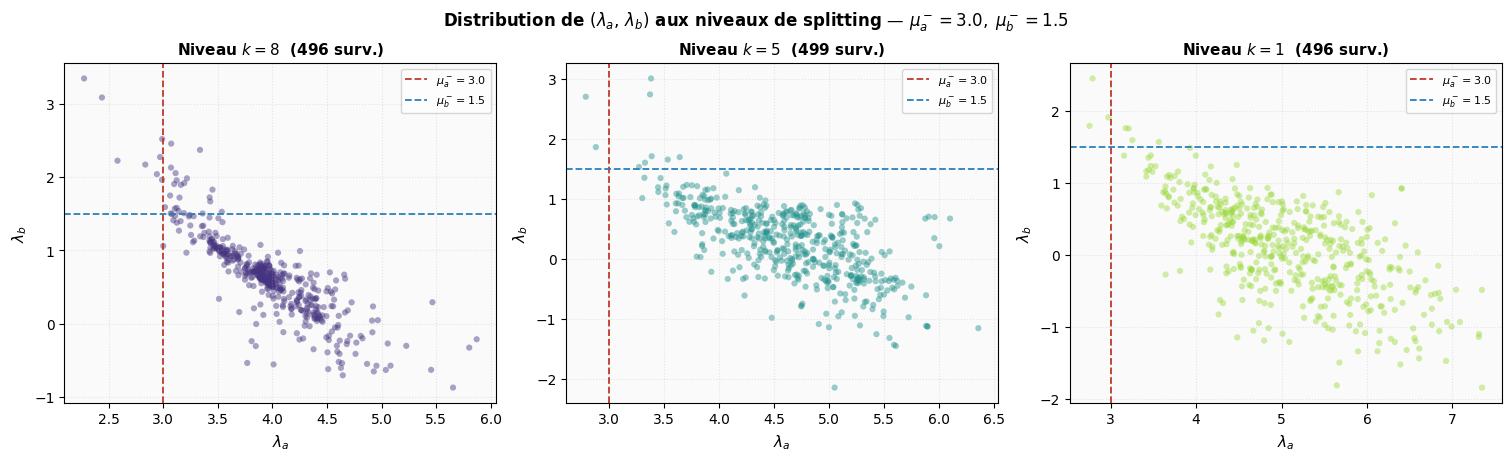


Phase en ligne depuis k=5 (400 échantillons)...
  Terminé en 0.04s
  p_offline=0.9586  p_online=0.9550  p_total=0.9155
  382 échantillons de Q_a2,  moyenne=14.29

Référence — splitting complet (§15)...
  p=0.9340  (500 échantillons)  en 0.17s
  moyenne Q_a2=14.32


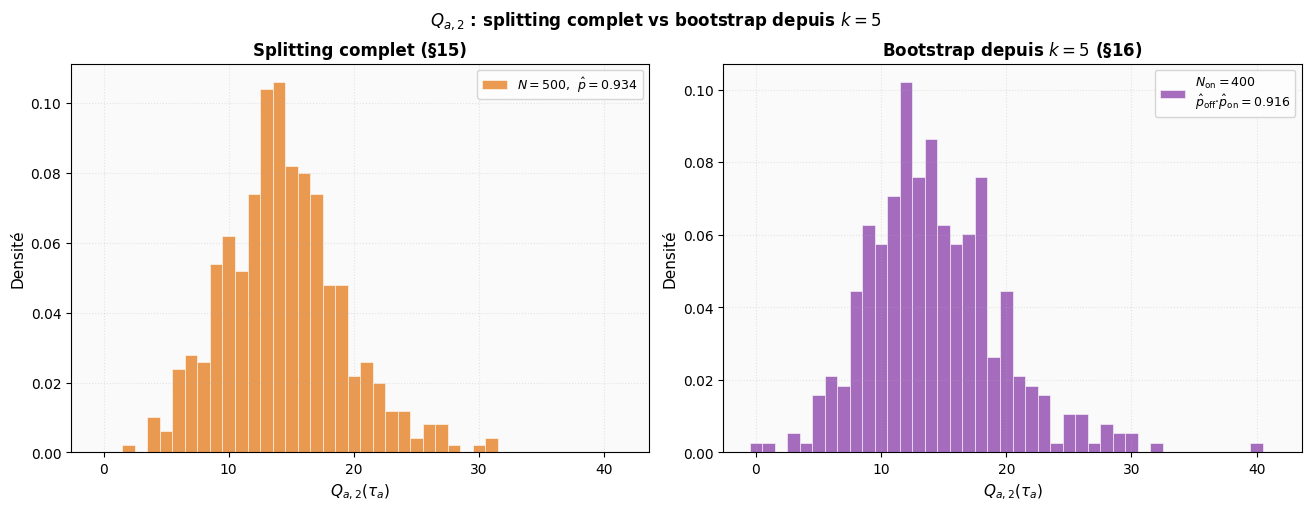


=== Cas bid (§16) : Q_{b,2} sachant tau_b < tau_a ===
Phase hors-ligne bid...
  Terminé en 0.13s
    k= 0 : 413 survivants  p_k=0.826
    k= 1 : 398 survivants  p_k=0.796
    k= 2 : 384 survivants  p_k=0.768
    k= 3 : 373 survivants  p_k=0.746
    k= 4 : 387 survivants  p_k=0.774
    k= 5 : 374 survivants  p_k=0.748
    k= 6 : 381 survivants  p_k=0.762
    k= 7 : 382 survivants  p_k=0.764
    k= 8 : 382 survivants  p_k=0.764
    k= 9 : 351 survivants  p_k=0.702


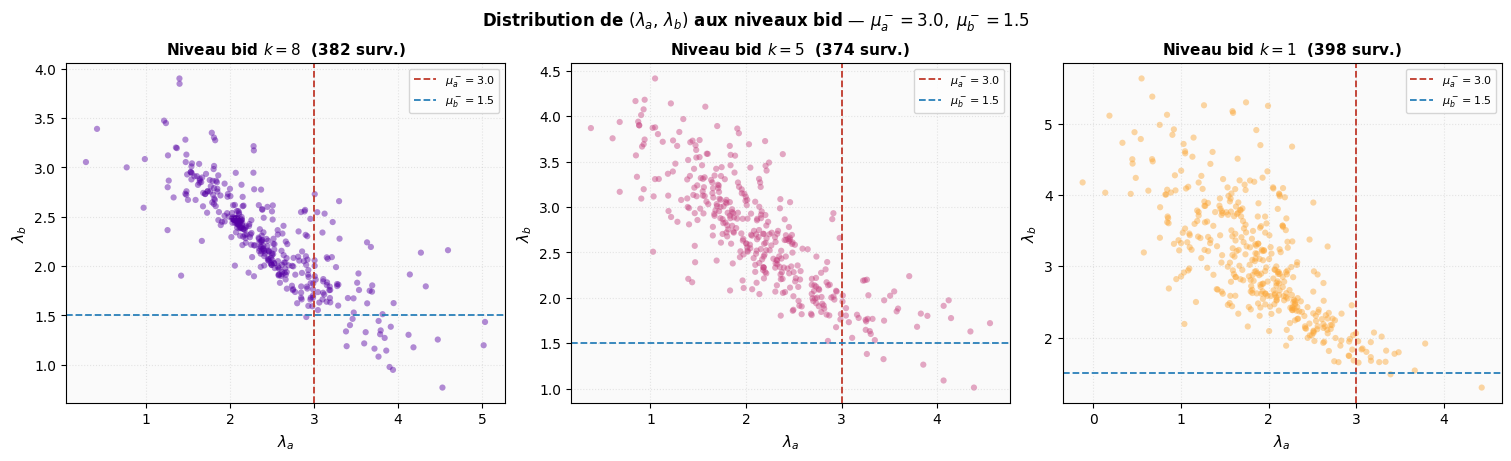


Phase en ligne bid depuis k=5 (400 échantillons)...
  Terminé en 0.04s
  p_offline=0.3122  p_online=0.2925  p_total=0.0913
  117 échantillons de Q_b2,  moyenne=13.93

Référence bid — splitting complet (§15)...
  p=0.0576  (500 échantillons)  en 0.27s
  moyenne Q_b2=13.49


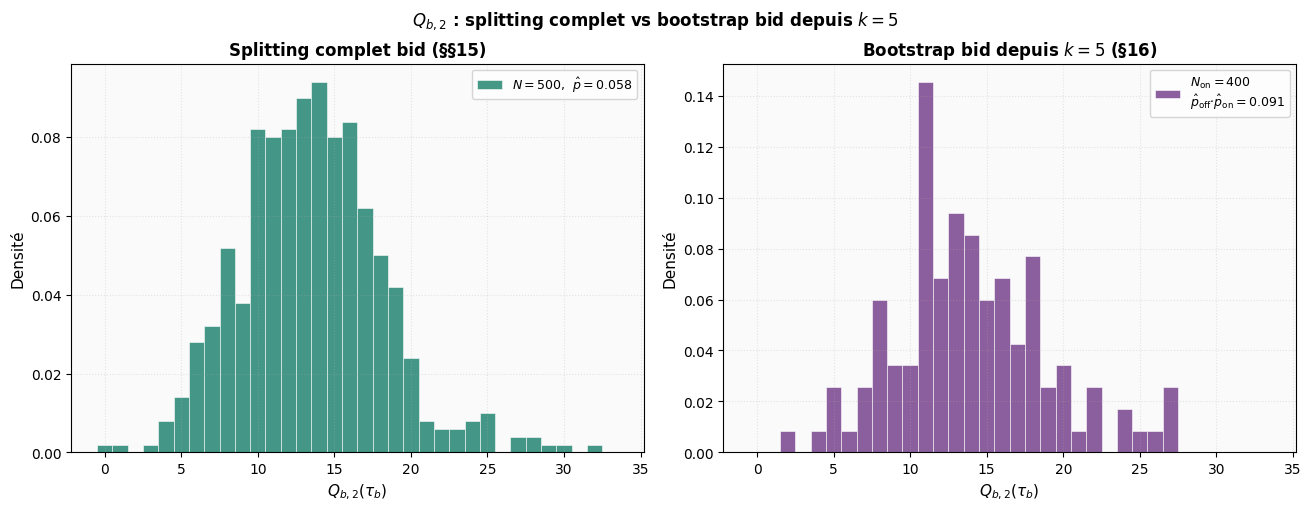

In [84]:
# ── Paramètres cas asymétrique ────────────────────────────────────────────────────────────────────────────────
MU_A16, MU_B16 = 3.0, 1.5
ALPHA16, BETA16 = 0.5, 1.0
A16, B16 = 0.8, 1.0
N_OFFLINE16 = 500
N_ONLINE16  = 400
START_K16   = 5

# ── Phase hors-ligne ──────────────────────────────────────────────────────────────────────────
print('Phase hors-ligne : collecte des états aux niveaux de splitting...')
t0 = _time.perf_counter()
lvl_states, lvl_probs = collect_level_states(
    N_OFFLINE16, MU_A16, MU_B16, ALPHA16, BETA16, A16, B16)
t_off = _time.perf_counter() - t0
print(f'  Terminé en {t_off:.2f}s')
for k in sorted(lvl_states.keys()):
    print(f'    k={k:2d} : {len(lvl_states[k]):3d} survivants  p_k={lvl_probs[k]:.3f}')

# ── Visualisation (λ_a, λ_b) aux niveaux 8, 5, 1 ───────────────────────────────────────────
levels_vis = [k for k in [8, 5, 1] if k in lvl_states and lvl_states[k]]
plot_lambda_at_levels(lvl_states, levels_vis, MU_A16, MU_B16)

# ── Phase en ligne depuis k = START_K16 ────────────────────────────────────────────────
print(f'\nPhase en ligne depuis k={START_K16} ({N_ONLINE16} échantillons)...')
t0 = _time.perf_counter()
q2_on, p_off, p_on = sample_and_complete(
    lvl_states, lvl_probs, START_K16, N_ONLINE16,
    MU_A16, MU_B16, ALPHA16, BETA16, A16, B16)
t_on = _time.perf_counter() - t0
p_tot = p_off * p_on
print(f'  Terminé en {t_on:.2f}s')
print(f'  p_offline={p_off:.4f}  p_online={p_on:.4f}  p_total={p_tot:.4f}')
if q2_on:
    print(f'  {len(q2_on)} échantillons de Q_a2,  moyenne={np.mean(q2_on):.2f}')

# ── Référence : splitting complet §15 ────────────────────────────────────────────────────────────
print('\nRéférence — splitting complet (§15)...')
t0 = _time.perf_counter()
q2_full, p_full = splitting_Q2_distribution(
    N_OFFLINE16, MU_A16, MU_B16, ALPHA16, BETA16, A16, B16)
t_full = _time.perf_counter() - t0
print(f'  p={p_full:.4f}  ({len(q2_full)} échantillons)  en {t_full:.2f}s')
if q2_full:
    print(f'  moyenne Q_a2={np.mean(q2_full):.2f}')

# ── Comparaison visuelle ────────────────────────────────────────────────────────────────────────────────
plot_q2_level_comparison(q2_full, q2_on, START_K16,
                          p_full, p_off, p_on,
                          N_OFFLINE16, N_ONLINE16)


# ── Cas bid (§16) : mu_b < mu_a donc tau_b < tau_a est l'événement rare ───────────────
print('\n=== Cas bid (§16) : Q_{b,2} sachant tau_b < tau_a ===')
print('Phase hors-ligne bid...')
t0 = _time.perf_counter()
lvl_states_bid, lvl_probs_bid = collect_level_states_bid(
    N_OFFLINE16, MU_A16, MU_B16, ALPHA16, BETA16, A16, B16)
t_off_bid = _time.perf_counter() - t0
print(f'  Terminé en {t_off_bid:.2f}s')
for k in sorted(lvl_states_bid.keys()):
    print(f'    k={k:2d} : {len(lvl_states_bid[k]):3d} survivants  p_k={lvl_probs_bid[k]:.3f}')

levels_vis_bid = [k for k in [8, 5, 1] if k in lvl_states_bid and lvl_states_bid[k]]
plot_lambda_at_levels_bid(lvl_states_bid, levels_vis_bid, MU_A16, MU_B16)

print(f'\nPhase en ligne bid depuis k={START_K16} ({N_ONLINE16} échantillons)...')
t0 = _time.perf_counter()
q2_on_bid, p_off_bid, p_on_bid = sample_and_complete_bid(
    lvl_states_bid, lvl_probs_bid, START_K16, N_ONLINE16,
    MU_A16, MU_B16, ALPHA16, BETA16, A16, B16)
t_on_bid = _time.perf_counter() - t0
p_tot_bid = p_off_bid * p_on_bid
print(f'  Terminé en {t_on_bid:.2f}s')
print(f'  p_offline={p_off_bid:.4f}  p_online={p_on_bid:.4f}  p_total={p_tot_bid:.4f}')
if q2_on_bid:
    print(f'  {len(q2_on_bid)} échantillons de Q_b2,  moyenne={np.mean(q2_on_bid):.2f}')

print('\nRéférence bid — splitting complet (§15)...')
t0 = _time.perf_counter()
q2_full_bid, p_full_bid = splitting_Q2_bid_distribution(
    N_OFFLINE16, MU_A16, MU_B16, ALPHA16, BETA16, A16, B16)
t_full_bid = _time.perf_counter() - t0
print(f'  p={p_full_bid:.4f}  ({len(q2_full_bid)} échantillons)  en {t_full_bid:.2f}s')
if q2_full_bid:
    print(f'  moyenne Q_b2={np.mean(q2_full_bid):.2f}')

plot_q2_level_comparison_bid(q2_full_bid, q2_on_bid, START_K16,
                              p_full_bid, p_off_bid, p_on_bid,
                              N_OFFLINE16, N_ONLINE16)
